# Brain CT Haemorrhage Detection — Combined Pipeline v3
### Dataset: [Brain Stroke CT Dataset](https://www.kaggle.com/datasets/ozguraslank/brain-stroke-ct-dataset)
### *(Contains: Normal vs Intracranial Haemorrhage — standalone DICOM files)*

**Pipeline stages:**

| Stage | Component | Description |
|-------|-----------|-------------|
| Pre-A | Skull Removal | Raw DICOM HU → skull-stripped DICOM (FIX 1–3) |
| Pre-B | Bleed Highlighting | Dynamic per-slice calibration + boundary exclusion + ring marking |
| Pre-C | Segment Analysis | 32×32 grid (16px cells) — HU stats + tissue heatmaps per slice |
| 1 | **DRRN** | CT denoising — CBAM + BatchNorm + Perceptual loss |
| 2 | **LapSRN** | 4× super-resolution — CBAM + BatchNorm (both v13 bug fixes) |
| 3 | **U-Net** | Bleed mask segmentation — trained on calibrated preprocessing masks |
| 4 | **Triage** | Priority score 0–100 proportional to bleed area |

**v3 additions from Colab notebook:**
- `load_dicom_metadata()` — robust recursive DICOM loader, builds full metadata DataFrame
- `segment_slice()` / `analyse_segment()` — 16px dense-grid sub-region HU analysis
- `calibrate_bleed_threshold()` — dynamic per-slice bleed window (replaces hardcoded 40–80 HU)
- `apply_boundary_exclusion()` — removes air-adjacent false-positive bleed pixels
- `plot_segment_heatmaps()` — 6-panel 32×32 heatmap visualisation
- `plot_hu_analysis()` — per-slice HU histogram + tissue bar chart

In [1]:
import os
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "9.4.2"

import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from torchvision import models
from torchvision.models import VGG19_Weights
from sklearn.model_selection import train_test_split
from scipy.ndimage import label, binary_erosion, binary_dilation, binary_fill_holes
from skimage.util import view_as_blocks
from tqdm import tqdm
from PIL import Image as PILImage
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import math, time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch      : {torch.__version__}")
print(f"Device     : {device}")
if device.type == "cuda":
    print(f"GPU        : {torch.cuda.get_device_name(0)}")

torch      : 2.5.1+rocm6.2
Device     : cuda
GPU        : AMD Radeon Graphics


In [4]:
import subprocess

subprocess.run([
    "pip", "install",
    "torchvision==0.20.1+rocm6.2",
    "--index-url", "https://download.pytorch.org/whl/rocm6.2",
    "--no-deps",
], check=True)

print("Done — restart the kernel")

Looking in indexes: https://download.pytorch.org/whl/rocm6.2
  Using cached https://download.pytorch.org/whl/rocm6.2/torchvision-0.20.1%2Brocm6.2-cp310-cp310-linux_x86_64.whl (2.6 MB)
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.25.0
    Uninstalling torchvision-0.25.0:
      Successfully uninstalled torchvision-0.25.0
Done — restart the kernel



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import subprocess

# Step 1: uninstall the nvidia torch and nvidia cuda packages
subprocess.run([
    "pip", "uninstall", "-y",
    "torch",
    "nvidia-cuda-cupti-cu12",
    "nvidia-cuda-nvrtc-cu12", 
    "nvidia-cuda-runtime-cu12",
    "cuda-bindings",
    "cuda-pathfinder",
], check=False)

# Step 2: install the ROCm torch that matches the rest of the environment
subprocess.run([
    "pip", "install",
    "torch==2.5.1+rocm6.2",
    "--index-url", "https://download.pytorch.org/whl/rocm6.2",
    "--no-deps",   # don't let it pull in nvidia deps again
], check=True)

print("Done — now restart the kernel")

Found existing installation: torch 2.10.0
Uninstalling torch-2.10.0:
  Successfully uninstalled torch-2.10.0
Found existing installation: nvidia-cuda-cupti-cu12 12.8.90
Uninstalling nvidia-cuda-cupti-cu12-12.8.90:
  Successfully uninstalled nvidia-cuda-cupti-cu12-12.8.90
Found existing installation: nvidia-cuda-nvrtc-cu12 12.8.93
Uninstalling nvidia-cuda-nvrtc-cu12-12.8.93:
  Successfully uninstalled nvidia-cuda-nvrtc-cu12-12.8.93
Found existing installation: nvidia-cuda-runtime-cu12 12.8.90
Uninstalling nvidia-cuda-runtime-cu12-12.8.90:
  Successfully uninstalled nvidia-cuda-runtime-cu12-12.8.90
Found existing installation: cuda-bindings 12.9.4
Uninstalling cuda-bindings-12.9.4:
  Successfully uninstalled cuda-bindings-12.9.4
Found existing installation: cuda-pathfinder 1.1.0
Uninstalling cuda-pathfinder-1.1.0:
  Successfully uninstalled cuda-pathfinder-1.1.0
Looking in indexes: https://download.pytorch.org/whl/rocm6.2
  Using cached https://download.pytorch.org/whl/rocm6.2/torch-2.5.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Done — now restart the kernel


In [2]:
import os
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "9.4.2"

import torch
print(torch.__version__)               # should show 2.5.1+rocm6.2
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.5.1+rocm6.2
CUDA available: True
GPU: AMD Radeon Graphics


In [2]:
import subprocess
subprocess.run([
    "pip", "install", "--upgrade", "--quiet",
    "numpy", "scikit-image", "pydicom",
    "albumentations", "scikit-learn", "tqdm", "matplotlib",
    "Pillow", "scipy", "pandas"
], check=True)
print("Dependencies ready.")

Dependencies ready.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import os, zipfile
os.environ['KAGGLE_CONFIG_DIR'] = os.getcwd()
!chmod 600 kaggle.json
!pip install --quiet kaggle
!kaggle datasets download -d ozguraslank/brain-stroke-ct-dataset

# Extract with Python — 'unzip' may not be available on all Colab instances
zip_path = 'brain-stroke-ct-dataset.zip'
out_dir  = './data'
if not os.path.exists(out_dir) or not os.listdir(out_dir):
    print(f'Extracting {zip_path} → {out_dir} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(out_dir)
    print('Done.')
else:
    print(f'{out_dir} already populated — skipping extraction.')

print('\nContents of ./data:')
for entry in sorted(os.listdir(out_dir)):
    print(f'  {entry}')


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Dataset URL: https://www.kaggle.com/datasets/ozguraslank/brain-stroke-ct-dataset
License(s): other
brain-stroke-ct-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
./data already populated — skipping extraction.

Contents of ./data:
  Brain_Stroke_CT_Dataset


## Cell 2 — Imports & Global HU Threshold Definitions

HU (Hounsfield Unit) reference ranges used throughout:
- **Air** `< -900 HU` — outside skull / sinuses
- **Water** `-10 to +10 HU` — CSF / fluid spaces
- **Brain** `+20 to +40 HU` — normal parenchyma (grey + white matter)
- **Bleed** `+50 to +90 HU` — hyperdense acute haemorrhage *(dynamically refined per slice in Cell 6)*

In [3]:
# Cell 2: Imports and global HU threshold definitions
# HU (Hounsfield Unit) reference ranges:
#   Air:              < -900 HU
#   Water:            -10 to +10 HU
#   Brain parenchyma: +20 to +40 HU
#   Bleed (hyperdense): +50 to +90 HU

import os
import numpy as np
import pydicom
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import (
    label, binary_erosion, binary_dilation, binary_fill_holes
)
from skimage.util import view_as_blocks
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# GLOBAL HU THRESHOLDS (will be refined dynamically per patient)
# ─────────────────────────────────────────────
HU_THRESHOLDS = {
    "air":        (-2000, -900),   # Air pockets / outside skull
    "water":      (  -10,    0),   # CSF / fluid
    "brain":      (    0,   40),   # Normal brain parenchyma (gray + white matter)
    "bleed":      (   40,   80),   # Hyperdense bleed (acute hemorrhage)
}

BOUNDARY_EXCLUSION_RADIUS = 5    # pixels — exclude bleed near negative-HU regions
PATCH_SIZE = 512                  # Each slice patch size (slices are already 512x512 here)

# ── Dataset paths ─────────────────────────────────────────────────────────────
# Layout: data/Brain_Stroke_CT_Dataset/Normal/DICOM/
#         data/Brain_Stroke_CT_Dataset/Bleeding/DICOM/
DATA_ROOT  = './data/Brain_Stroke_CT_Dataset'
NORMAL_DIR = os.path.join(DATA_ROOT, 'Normal',   'DICOM')
BLEED_DIR  = os.path.join(DATA_ROOT, 'Bleeding', 'DICOM')

# ── Output directories ────────────────────────────────────────────────────────
PROCESSED_DIR         = './processed'
skull_removed_dir     = os.path.join(PROCESSED_DIR, 'skull_removed')
bleed_highlighted_dir = os.path.join(PROCESSED_DIR, 'bleed_highlighted')
os.makedirs(skull_removed_dir,     exist_ok=True)
os.makedirs(bleed_highlighted_dir, exist_ok=True)

# ── Preprocessing config (haemorrhage pipeline) ───────────────────────────────
BOUNDARY_THICKNESS = 2    # Highlight ring thickness (pixels each side)
BRAIN_RIM_EROSION  = 10   # Pixels stripped from brain boundary
MIN_BLEED_SIZE     = 200  # Min region size (px) — filters noise clusters
MIN_BRAIN_PIXELS   = 5000 # Skip slices with fewer brain pixels
MIN_BRAIN_HU       = -100 # Skip slices where brain HU min is below this

print("✅ Imports complete. HU thresholds loaded:")
for k, v in HU_THRESHOLDS.items():
    print(f"   {k:>8s}: {v[0]:>6} to {v[1]:>6} HU")

✅ Imports complete. HU thresholds loaded:
        air:  -2000 to   -900 HU
      water:    -10 to      0 HU
      brain:      0 to     40 HU
      bleed:     40 to     80 HU


## Cell 3 — Robust DICOM Metadata Loader
Recursively walks the dataset directory, attempts to read **every file** as DICOM (no extension filtering — `pydicom` auto-detects format). Builds a full metadata DataFrame used for sorting and patient grouping downstream.

In [4]:
# ── Diagnostic: inspect first file to verify DICOM structure ────────────────
import pydicom, os

_sample = None
for root, _, files in os.walk(NORMAL_DIR):
    for f in files:
        _sample = os.path.join(root, f)
        break
    if _sample: break

if _sample:
    print(f'Sample file: {_sample}')
    try:
        ds = pydicom.dcmread(_sample, stop_before_pixels=True, force=True)
        print(f'  Modality  : {getattr(ds, "Modality",  "MISSING")}')
        print(f'  Rows      : {getattr(ds, "Rows",      "MISSING")}')
        print(f'  Columns   : {getattr(ds, "Columns",   "MISSING")}')
        print(f'  SOPClassUID: {getattr(ds, "SOPClassUID", "MISSING")}')
        print(f'  Tags present: {len(ds)}')
        # Show first 10 tags
        for i, elem in enumerate(ds):
            print(f'    [{i}] {elem.tag}  {elem.name}  = {str(elem.value)[:60]}')
            if i >= 9: break
    except Exception as e:
        print(f'  ❌ pydicom error: {e}')
        # Try reading raw bytes
        with open(_sample, 'rb') as fh:
            header = fh.read(256)
        print(f'  First 16 bytes (hex): {header[:16].hex()}')
        print(f'  DICM magic at 128: {header[128:132]}')
else:
    print('No files found in NORMAL_DIR')

Sample file: ./data/Brain_Stroke_CT_Dataset/Normal/DICOM/15946.dcm
  Modality  : MISSING
  Rows      : 512
  Columns   : 512
  SOPClassUID: 1.2.840.10008.5.1.4.1.1.2
  Tags present: 16
    [0] (0008,0016)  SOP Class UID  = 1.2.840.10008.5.1.4.1.1.2
    [1] (0018,0050)  Slice Thickness  = 4
    [2] (0028,0002)  Samples per Pixel  = 1
    [3] (0028,0004)  Photometric Interpretation  = MONOCHROME2
    [4] (0028,0010)  Rows  = 512
    [5] (0028,0011)  Columns  = 512
    [6] (0028,0030)  Pixel Spacing  = [0.490234375, 0.490234375]
    [7] (0028,0100)  Bits Allocated  = 16
    [8] (0028,0101)  Bits Stored  = 12
    [9] (0028,0102)  High Bit  = 11


In [5]:
# Cell 3 (FIXED): Load DICOMs with robust path detection

import os, pydicom, pandas as pd
from tqdm import tqdm

def load_dicom_metadata(base_dir: str) -> pd.DataFrame:
    """
    Recursively walk base_dir, attempt to read EVERY file as a DICOM
    (pydicom auto-detects format — no extension filtering needed).
    """
    records = []
    all_files = []

    # ── Collect all files recursively ───────────────────────────
    for root, dirs, files in os.walk(base_dir):
        for f in files:
            all_files.append(os.path.join(root, f))

    print(f"📂 Found {len(all_files)} total files under: {base_dir}")
    if len(all_files) == 0:
        print("❌ No files found. Check BASE_DIR path!")
        return pd.DataFrame()

    # ── Try reading each file as DICOM ──────────────────────────
    skipped = 0
    for fpath in tqdm(all_files, desc="Reading DICOMs"):
        try:
            ds = pydicom.dcmread(fpath, force=True)  # full read — Rows tag absent with stop_before_pixels

            # Valid CT slice must have Rows > 0
            rows = int(getattr(ds, 'Rows', 0))
            if rows == 0:
                skipped += 1
                continue

            # Reconstruct relative folder parts
            rel = os.path.relpath(fpath, base_dir)
            parts = rel.split(os.sep)

            records.append({
                "patient_folder":    parts[0] if len(parts) > 0 else '',
                "date_folder":       parts[1] if len(parts) > 1 else '',
                "series_folder":     parts[2] if len(parts) > 2 else '',
                "filename":          parts[-1],
                "full_path":         fpath,
                "PatientID":         str(getattr(ds, 'PatientID',         'Unknown')),
                "PatientName":       str(getattr(ds, 'PatientName',       'Unknown')),
                "StudyDate":         str(getattr(ds, 'StudyDate',         '')),
                "StudyInstanceUID":  str(getattr(ds, 'StudyInstanceUID',  '')),
                "SeriesInstanceUID": str(getattr(ds, 'SeriesInstanceUID', '')),
                "SeriesDescription": str(getattr(ds, 'SeriesDescription', 'Unknown')),
                "InstanceNumber":    int(getattr(ds, 'InstanceNumber',    0)),
                "SliceThickness":    float(getattr(ds, 'SliceThickness',  0)),
                "KVP":               float(getattr(ds, 'KVP',             0)),
                "Modality":          str(getattr(ds, 'Modality',          '')),
                "Rows":              rows,
                "Columns":           int(getattr(ds, 'Columns',           0)),
                "PixelSpacing":      list(getattr(ds, 'PixelSpacing',     [0, 0])),
            })
        except Exception:
            skipped += 1   # silently skip non-DICOM files (jpgs, txts, etc.)

    print(f"   ✅ Valid DICOMs parsed : {len(records)}")
    print(f"   ⚠️  Skipped (non-DICOM) : {skipped}")

    return pd.DataFrame(records)


# ── Verify dataset paths ─────────────────────────────────────────
print("📁 Checking dataset directories:")
for path, name in [(NORMAL_DIR, 'Normal/DICOM'), (BLEED_DIR, 'Bleeding/DICOM')]:
    exists = os.path.isdir(path)
    count  = len(os.listdir(path)) if exists else 0
    status = 'DIR' if exists else 'MISSING'
    print(f"   [{status}] {name}  ({count} files)")

# ── Load skull-removed DICOMs (or raw data if Part A not yet run) ─
BASE_DIR = (skull_removed_dir
            if os.path.isdir(skull_removed_dir) and os.listdir(skull_removed_dir)
            else DATA_ROOT)
print(f"\nLoading from: {BASE_DIR}")

if not os.path.exists(BASE_DIR):
    print(f"\n❌ BASE_DIR not found: {BASE_DIR}")
    print("   Check DATA_ROOT in Cell 2.")
else:
    df = load_dicom_metadata(BASE_DIR)

    if len(df) == 0:
        print("\n❌ DataFrame is empty — no valid DICOMs parsed.")
    else:
        print(f"\n✅ Total DICOMs: {len(df)}")
        print("\nSeries types:")
        print(df['SeriesDescription'].value_counts().rename('count'))
        print("\nPatients:")
        print(df['PatientID'].value_counts().rename('count'))
        display(df.head())

# ── Label inference: 'Bleeding' folder → 1, 'Normal' → 0 ────────
def infer_label(full_path, root=DATA_ROOT):
    """Infer binary label from folder name. Works for any subtree of DATA_ROOT."""
    rel_lower = os.path.relpath(full_path, root).lower()
    for kw in ('bleeding', 'bleed', 'haemorrhage', 'hemorrhage', 'abnormal'):
        if kw in rel_lower:
            return 1
    return 0

# Add label to df (skull-removed or raw — inherits folder structure)
if len(df) > 0:
    df['label'] = df['full_path'].apply(infer_label)

# ── Build df_orig: labelled DataFrame over the raw DICOM tree ────
df_orig = load_dicom_metadata(DATA_ROOT)
if len(df_orig) > 0:
    df_orig['label'] = df_orig['full_path'].apply(infer_label)
    print(f"\nOriginal dataset — "
          f"Bleeding: {(df_orig['label']==1).sum()} | "
          f"Normal: {(df_orig['label']==0).sum()}")

📁 Checking dataset directories:
   [DIR] Normal/DICOM  (4427 files)
   [DIR] Bleeding/DICOM  (1093 files)

Loading from: ./processed/skull_removed
📂 Found 5520 total files under: ./processed/skull_removed


Reading DICOMs: 100% 5520/5520 [00:01<00:00, 3042.16it/s]

   ✅ Valid DICOMs parsed : 5520
   ⚠️  Skipped (non-DICOM) : 0

✅ Total DICOMs: 5520

Series types:
SeriesDescription
Unknown    5520
Name: count, dtype: int64

Patients:
PatientID
Unknown    5520
Name: count, dtype: int64


,patient_folder,date_folder,series_folder,filename,full_path,PatientID,PatientName,StudyDate,StudyInstanceUID,SeriesInstanceUID,SeriesDescription,InstanceNumber,SliceThickness,KVP,Modality,Rows,Columns,PixelSpacing
0,Bleeding,DICOM,10887.dcm,10887.dcm,./processed/skull_removed/Bleeding/DICOM/10887...,Unknown,Unknown,,,,Unknown,0,2.50,0.0,,512,512,"[0.625, 0.625]"
1,Bleeding,DICOM,15736.dcm,15736.dcm,./processed/skull_removed/Bleeding/DICOM/15736...,Unknown,Unknown,,,,Unknown,0,5.00,0.0,,512,512,"[0.488, 0.488]"
2,Bleeding,DICOM,15475.dcm,15475.dcm,./processed/skull_removed/Bleeding/DICOM/15475...,Unknown,Unknown,,,,Unknown,0,5.00,0.0,,512,512,"[0.544921875, 0.544921875]"
3,Bleeding,DICOM,12666.dcm,12666.dcm,./processed/skull_removed/Bleeding/DICOM/12666...,Unknown,Unknown,,,,Unknown,0,3.00,0.0,,512,512,"[0.759766, 0.759766]"
4,Bleeding,DICOM,14668.dcm,14668.dcm,./processed/skull_removed/Bleeding/DICOM/14668...,Unknown,Unknown,,,,Unknown,0,3.75,0.0,,512,512,"[0.488281, 0.488281]"


📂 Found 12133 total files under: ./data/Brain_Stroke_CT_Dataset


Reading DICOMs: 100% 12133/12133 [00:02<00:00, 5123.31it/s]


   ✅ Valid DICOMs parsed : 5520
   ⚠️  Skipped (non-DICOM) : 6613

Original dataset — Bleeding: 1093 | Normal: 4427


## Cell 3b — Core Utility Functions
`get_hu_array`, `segment_slice`, `analyse_segment` — required by all downstream cells.

In [6]:
# Cell 3b: Core utility functions required by all downstream cells.
# Run this immediately after Cell 3 (the DICOM loader).
#
# Functions defined here:
#   - get_hu_array       : load a DICOM file → 512×512 HU float array
#   - segment_slice      : divide 512×512 HU array → list of 16px sub-regions
#   - analyse_segment    : compute HU stats + tissue masks for one sub-region

import numpy as np
import pydicom


def get_hu_array(dcm_path: str) -> np.ndarray:
    """
    Read a DICOM file and return its pixel data converted to HU values.

    Formula:  HU = pixel_value * RescaleSlope + RescaleIntercept
    Both tags default to (slope=1, intercept=0) if absent.

    Args:
        dcm_path : full path to a .dcm file

    Returns:
        hu : 2D float32 numpy array of shape (Rows, Cols)

    Raises:
        AttributeError : if the file has no pixel data (DICOMDIR, SR, etc.)
    """
    ds = pydicom.dcmread(dcm_path, force=True)
    if 0x7FE00010 not in ds:
        raise AttributeError(
            f"No pixel data in DICOM: {dcm_path}\n"
            "This is likely a DICOMDIR, SR, or metadata-only file."
        )
    pixels    = ds.pixel_array.astype(np.float32)
    slope     = float(getattr(ds, 'RescaleSlope',     1))
    intercept = float(getattr(ds, 'RescaleIntercept', 0))
    hu        = pixels * slope + intercept
    return hu


# Fallback default — overridden at runtime if SEGMENT_SIZE is
# already defined (e.g. when Cell 19 has been run first).
if "SEGMENT_SIZE" not in dir():
    SEGMENT_SIZE = 16  # matches Cell 19

def segment_slice(hu_array: np.ndarray,
                  segment_size: int = None) -> list:
    """
    Divide a 512×512 HU array into non-overlapping square sub-regions.

    For SEGMENT_SIZE=16 this produces a 32×32 grid = 1024 sub-regions.

    Args:
        hu_array     : 2D float32 numpy array, expected shape (512, 512)
        segment_size : side length of each sub-region in pixels

    Returns:
        segments : list of dicts, each containing —
            'patch'      : 2D np.ndarray  (segment_size × segment_size)
            'row_idx'    : grid row index  (0-based)
            'col_idx'    : grid col index  (0-based)
            'row_start'  : pixel row start in the original 512×512 image
            'col_start'  : pixel col start in the original 512×512 image
    """
    if segment_size is None:
        segment_size = SEGMENT_SIZE
    segments = []
    grid_n   = 512 // segment_size

    for r in range(grid_n):
        for c in range(grid_n):
            rs = r * segment_size
            cs = c * segment_size
            segments.append({
                "patch":     hu_array[rs:rs+segment_size,
                                      cs:cs+segment_size],
                "row_idx":   r,
                "col_idx":   c,
                "row_start": rs,
                "col_start": cs,
            })
    return segments


def analyse_segment(seg: dict, thresholds: dict) -> dict:
    """
    For one sub-region dict (from segment_slice), compute:
        - HU min, max, mean, std
        - Per-tissue-class: pixel count, mean HU, local positions,
          global positions (within full 512×512 image), boolean mask

    Args:
        seg        : dict from segment_slice (must contain 'patch',
                     'row_start', 'col_start')
        thresholds : dict of {label: (hu_lo, hu_hi)}  e.g. HU_THRESHOLDS

    Returns:
        result : input dict enriched with per-tissue analysis fields
    """
    patch  = seg["patch"]
    result = {
        **seg,
        "hu_min":  float(patch.min()),
        "hu_max":  float(patch.max()),
        "hu_mean": float(patch.mean()),
        "hu_std":  float(patch.std()),
    }

    for label, (lo, hi) in thresholds.items():
        mask      = (patch >= lo) & (patch <= hi)
        positions = np.argwhere(mask)

        global_positions = positions + np.array(
            [seg["row_start"], seg["col_start"]])

        result[f"{label}_mask"]             = mask
        result[f"{label}_count"]            = int(mask.sum())
        result[f"{label}_mean_hu"]          = (float(patch[mask].mean())
                                                if mask.any() else np.nan)
        result[f"{label}_positions_local"]  = positions
        result[f"{label}_positions_global"] = global_positions

    return result


# ── Sanity check ──────────────────────────────────────────────────
print("✅ Cell 3b ready — core utility functions defined:")
print("   • get_hu_array(dcm_path)")
print(f"   • segment_slice(hu_array, segment_size={SEGMENT_SIZE})")
print("   • analyse_segment(seg, thresholds)")

print(f"\nSanity check: loading first slice of first patient...")
first_row = df_orig.sort_values(['PatientID', 'InstanceNumber']).iloc[0]
test_hu   = get_hu_array(first_row['full_path'])

test_segs    = segment_slice(test_hu)
test_results = [analyse_segment(s, HU_THRESHOLDS) for s in test_segs]

print(f"  Slice shape     : {test_hu.shape}")
print(f"  Sub-regions     : {len(test_results)}")
print(f"  First sub-region (row=0, col=0):")
r0 = test_results[0]
print(f"    HU  min={r0['hu_min']:.1f}  max={r0['hu_max']:.1f}  "
      f"mean={r0['hu_mean']:.1f}  std={r0['hu_std']:.1f}")
for lbl in HU_THRESHOLDS:
    mhu = r0[f'{lbl}_mean_hu']
    mhu_str = f"{mhu:.1f}" if not np.isnan(mhu) else "n/a"
    print(f"    {lbl:>8s}: {r0[f'{lbl}_count']:>5} px  mean HU={mhu_str}")
# True centre sub-region (row=16, col=16) for a 32×32 grid
centre = next(s for s in test_results if s['row_idx'] == 16 and s['col_idx'] == 16)
print(f"Centre sub-region (row={centre['row_idx']}, col={centre['col_idx']}):")
print(f"  HU  min={centre['hu_min']:.1f}  max={centre['hu_max']:.1f}  "
      f"mean={centre['hu_mean']:.1f}  std={centre['hu_std']:.1f}")
for lbl in HU_THRESHOLDS:
    mhu = centre[f'{lbl}_mean_hu']
    mhu_str = f"{mhu:.1f}" if not np.isnan(mhu) else "n/a"
    print(f"  {lbl:>8s}: {centre[f'{lbl}_count']:>5} px  mean HU={mhu_str}")

✅ Cell 3b ready — core utility functions defined:
   • get_hu_array(dcm_path)
   • segment_slice(hu_array, segment_size=16)
   • analyse_segment(seg, thresholds)

Sanity check: loading first slice of first patient...
  Slice shape     : (512, 512)
  Sub-regions     : 1024
  First sub-region (row=0, col=0):
    HU  min=-3024.0  max=-3024.0  mean=-3024.0  std=0.0
         air:     0 px  mean HU=n/a
       water:     0 px  mean HU=n/a
       brain:     0 px  mean HU=n/a
       bleed:     0 px  mean HU=n/a
Centre sub-region (row=16, col=16):
  HU  min=3.0  max=31.0  mean=17.7  std=6.3
       air:     0 px  mean HU=n/a
     water:     0 px  mean HU=n/a
     brain:   256 px  mean HU=17.7
     bleed:     0 px  mean HU=n/a


## Cell 6 — Dynamic Per-Slice Bleed Threshold Calibration
Instead of a fixed 40–80 HU window, the bleed band is derived from the brain parenchyma distribution of each slice:
- `bleed_lo = max(45, brain_mean + 1.5 × brain_std)`
- `bleed_hi = min(100, bleed_lo + 40)`

In [7]:
# Cell 6: Dynamically calibrate bleed HU thresholds per slice
# Strategy:
#   • Extract pixels within the nominal brain parenchyma range
#   • Compute local mean & std of those pixels
#   • Set bleed_lo = brain_mean + 1.5 * brain_std  (floor: 45 HU)
#   • Set bleed_hi = bleed_lo + 40 HU              (ceiling: 100 HU)
#   • All other tissue thresholds remain unchanged

def calibrate_bleed_threshold(hu_array: np.ndarray,
                               base_thresholds: dict,
                               verbose: bool = True) -> dict:
    """
    Dynamically adjust the bleed HU band for a single slice.

    Args:
        hu_array         : full 512×512 HU array for the slice
        base_thresholds  : global HU_THRESHOLDS dict
        verbose          : print calibration details

    Returns:
        thresholds : copy of base_thresholds with updated 'bleed' band
    """
    thresholds = {k: v for k, v in base_thresholds.items()}   # shallow copy

    brain_lo, brain_hi = base_thresholds["brain"]
    brain_pixels = hu_array[(hu_array >= brain_lo) & (hu_array <= brain_hi)]

    if len(brain_pixels) < 100:
        # Fallback: top/bottom slices often have very little brain tissue
        if verbose:
            print("   ⚠️  Insufficient brain pixels — using default bleed thresholds.")
        return thresholds

    brain_mean = brain_pixels.mean()
    brain_std  = brain_pixels.std()

    bleed_lo = max(45.0,  brain_mean + 1.5 * brain_std)
    bleed_hi = min(100.0, bleed_lo   + 40.0)

    thresholds["bleed"] = (round(bleed_lo, 1), round(bleed_hi, 1))

    if verbose:
        print(f"   Brain pixels : {len(brain_pixels):,}  "
              f"mean={brain_mean:.1f} HU  std={brain_std:.1f} HU")
        print(f"   → Calibrated bleed window : "
              f"{thresholds['bleed'][0]} – {thresholds['bleed'][1]} HU")

    return thresholds


print("✅ Cell 6 ready — dynamic bleed calibration function defined.")

✅ Cell 6 ready — dynamic bleed calibration function defined.


## Cell 7 — Boundary Exclusion
Removes bleed candidate pixels within `BOUNDARY_EXCLUSION_RADIUS` pixels of any air region (HU < -900).  
Air-adjacent voxels often have partial-volume artefacts that mimic hyperdensity — especially important for 16px sub-regions where a single border artefact dominates the whole patch.

In [8]:
# Cell 7: Exclude bleed candidates within BOUNDARY_EXCLUSION_RADIUS pixels
#         of any negative-HU (air) region.
#
# Why: Air-adjacent voxels often have partial-volume artefacts that
#      mimic hyperdensity — excluding them reduces false positives.
#
# For 16px sub-regions this is especially important because each
# sub-region is small; a single air-border artefact can dominate
# the entire patch if not excluded.

BOUNDARY_EXCLUSION_RADIUS = 5   # pixels — set in Cell 2, redefined here for clarity

def apply_boundary_exclusion(bleed_mask: np.ndarray,
                              hu_patch: np.ndarray,
                              radius: int = BOUNDARY_EXCLUSION_RADIUS):
    """
    Remove bleed pixels within `radius` pixels of any air voxel.

    Steps:
      1. Build air mask  : pixels where HU < -900
      2. Dilate air mask : expand by `radius` using a square structuring element
      3. Subtract        : zero out bleed pixels inside the dilated air zone

    Args:
        bleed_mask : boolean 2D array — initial bleed candidates (patch-sized)
        hu_patch   : 2D float array   — raw HU values for the same patch
        radius     : exclusion radius in pixels

    Returns:
        cleaned_mask : boolean 2D array — artefacts removed
        n_removed    : int              — number of pixels removed
    """
    air_mask    = hu_patch < -900
    struct      = np.ones((2*radius + 1, 2*radius + 1), dtype=bool)
    dilated_air = binary_dilation(air_mask, structure=struct)

    cleaned_mask = bleed_mask & ~dilated_air
    n_removed    = int(bleed_mask.sum()) - int(cleaned_mask.sum())

    return cleaned_mask, n_removed


print(f"✅ Cell 7 ready — boundary exclusion defined  "
      f"(radius = {BOUNDARY_EXCLUSION_RADIUS} px).")
print(f"   Note: for 16×16 sub-regions a radius of {BOUNDARY_EXCLUSION_RADIUS}px "
      f"covers ~{BOUNDARY_EXCLUSION_RADIUS/16*100:.0f}% of each patch width.")

✅ Cell 7 ready — boundary exclusion defined  (radius = 5 px).
   Note: for 16×16 sub-regions a radius of 5px covers ~31% of each patch width.


---
## Part A & B — Preprocessing Pipeline
All 5 fixes from the original haemorrhage pipeline retained.  
**v3 upgrades:** `get_bleed_mask()` now calls `calibrate_bleed_threshold()` (Cell 6) and `apply_boundary_exclusion()` (Cell 7) before applying `MIN_BLEED_SIZE` filtering.

In [9]:
# ── Preprocessing helper functions (haemorrhage pipeline, all 5 fixes) ────────

def preprocess_hu(hu_image: np.ndarray) -> np.ndarray:
    """
    FIX 1: Remap DICOM sentinel values (≤ -2000) to -1000 (air).
    Prevents sentinel pixels from corrupting brain mask or HU stats.
    """
    hu_image = hu_image.copy().astype(np.float32)
    hu_image[hu_image <= -2000] = -1000
    return hu_image


def read_dicom_hu(dcm_path: str):
    """
    Read a standalone DICOM and return (ds, slope, intercept, hu_image).
    FIX 1 applied immediately after HU conversion.
    """
    ds        = pydicom.dcmread(dcm_path, force=True)
    slope     = float(getattr(ds, 'RescaleSlope',     1.0))
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
    raw_hu    = ds.pixel_array.astype(np.float32) * slope + intercept
    return ds, slope, intercept, preprocess_hu(raw_hu)


def get_brain_mask(hu_image: np.ndarray, rim_erosion: int = 10):
    """
    FIX 3: Returns None if no valid brain region found.
    Isolates brain parenchyma via soft-tissue thresholding,
    hole-filling, largest-component selection, and boundary erosion.
    """
    tissue_mask = (hu_image >= 0) & (hu_image <= 100)
    filled      = binary_fill_holes(tissue_mask)
    labeled, n  = label(filled)
    if n == 0:
        return None
    sizes      = np.bincount(labeled.ravel())
    sizes[0]   = 0
    brain_mask = labeled == sizes.argmax()
    brain_mask = binary_erosion(brain_mask, iterations=rim_erosion)
    return brain_mask


def is_valid_slice(brain_mask, hu_image: np.ndarray):
    """
    FIX 4: Validate a slice before processing.
    Rejects: no mask / too few brain pixels / air inside brain region.
    """
    if brain_mask is None:
        return False, "no brain mask"
    if brain_mask.sum() < MIN_BRAIN_PIXELS:
        return False, f"too few brain pixels ({int(brain_mask.sum())})"
    brain_hu_min = float(hu_image[brain_mask].min())
    if brain_hu_min < MIN_BRAIN_HU:
        return False, f"brain mask contains air (min HU={brain_hu_min:.1f})"
    return True, "ok"


def get_bleed_mask(hu_image: np.ndarray, brain_mask: np.ndarray) -> np.ndarray:
    """
    Detect hyperdense bleed regions inside the validated brain mask.

    v3 upgrades over original pipeline:
      1. Bleed HU window calibrated dynamically per slice (Cell 6)
         instead of hardcoded 40–80 HU.
      2. Boundary exclusion applied before size filtering (Cell 7)
         to remove air-adjacent partial-volume artefacts.
      3. FIX 5: MIN_BLEED_SIZE = 200 px retained.
    """
    # Step 1: Dynamic calibration of bleed window
    cal_thresholds = calibrate_bleed_threshold(hu_image, HU_THRESHOLDS,
                                               verbose=False)
    bleed_lo, bleed_hi = cal_thresholds["bleed"]

    # Step 2: Initial hyperdense mask inside brain
    raw_bleed = (hu_image >= bleed_lo) & (hu_image <= bleed_hi) & brain_mask

    # Step 3: Boundary exclusion — remove air-adjacent artefacts (Cell 7)
    raw_bleed, _ = apply_boundary_exclusion(raw_bleed, hu_image,
                                             radius=BOUNDARY_EXCLUSION_RADIUS)

    # Step 4: FIX 5 — filter out noise clusters < MIN_BLEED_SIZE
    labeled, n_features = label(raw_bleed)
    if n_features == 0:
        return np.zeros_like(raw_bleed, dtype=bool)
    sizes       = np.bincount(labeled.ravel())
    sizes[0]    = 0
    large_bleed = np.zeros_like(raw_bleed, dtype=bool)
    for lbl_id in range(1, n_features + 1):
        if sizes[lbl_id] >= MIN_BLEED_SIZE:
            large_bleed |= (labeled == lbl_id)
    return large_bleed


print("✅ Preprocessing functions ready (all 5 fixes + v3 calibration + boundary exclusion).")

✅ Preprocessing functions ready (all 5 fixes + v3 calibration + boundary exclusion).


In [10]:
# ── Part A: Skull Removal ─────────────────────────────────────────────────────
import pydicom.uid

skull_skip = []

for _, row in tqdm(df_orig.iterrows(), total=len(df_orig), desc="Skull removal"):
    dcm_path = row['full_path']
    try:
        ds, slope, intercept, hu_image = read_dicom_hu(dcm_path)

        skull_mask = (
            ((hu_image >= 100) & (hu_image <= 299)) |
            ((hu_image >= 300) & (hu_image <= 999)) |
            (hu_image >= 1000)
        )
        hu_skull_removed             = hu_image.copy()
        hu_skull_removed[skull_mask] = hu_image.min()

        raw_pixel_skull_removed = (hu_skull_removed - intercept) / slope

        # ── FIX: decompress in-place, then switch to uncompressed transfer
        # syntax before writing. Without this, pydicom tries to write
        # compressed pixel data without re-encapsulating it → ValueError.
        try:
            ds.decompress()
        except Exception:
            pass  # already uncompressed — safe to ignore

        ds.file_meta.TransferSyntaxUID = pydicom.uid.ExplicitVRLittleEndian
        ds.is_implicit_VR              = False
        ds.is_little_endian            = True

        ds.PixelData = raw_pixel_skull_removed.astype(
            ds.pixel_array.dtype).tobytes()

        rel       = os.path.relpath(dcm_path, DATA_ROOT)
        save_path = os.path.join(skull_removed_dir, rel)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        ds.save_as(save_path, write_like_original=False)

    except Exception as e:
        skull_skip.append((os.path.basename(dcm_path), str(e)))

print(f"\n✅ Skull removal complete → {skull_removed_dir}")
if skull_skip:
    print(f"   Errors ({len(skull_skip)}):")
    for name, err in skull_skip[:5]:
        print(f"   {name}: {err}")
else:
    print("   No errors.")

Skull removal: 100% 5520/5520 [05:57<00:00, 15.42it/s]


✅ Skull removal complete → ./processed/skull_removed
   No errors.


In [11]:
# ── Part B: Bleed Detection & Boundary Highlighting ───────────────────────────
# v3: get_bleed_mask() now uses calibrated threshold + boundary exclusion.

skull_dcm_files = [
    os.path.join(root, f)
    for root, _, files in os.walk(skull_removed_dir)
    for f in sorted(files) if f.lower().endswith('.dcm')
]
print(f"Processing {len(skull_dcm_files)} skull-removed DICOMs…")

highlight_skip = []

for skull_path in tqdm(skull_dcm_files, desc="Bleed highlighting"):
    try:
        ds, slope, intercept, hu_image = read_dicom_hu(skull_path)
        brain_mask = get_brain_mask(hu_image, rim_erosion=BRAIN_RIM_EROSION)

        rel       = os.path.relpath(skull_path, skull_removed_dir)
        save_path = os.path.join(bleed_highlighted_dir, rel)
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        # FIX 4: validate before detection
        valid, reason = is_valid_slice(brain_mask, hu_image)
        if not valid:
            highlight_skip.append((os.path.basename(skull_path), reason))
            ds.save_as(save_path)
            continue

        # v3: calibrated bleed mask with boundary exclusion (inside get_bleed_mask)
        bleed_mask = get_bleed_mask(hu_image, brain_mask)

        if np.any(bleed_mask):
            dilated        = binary_dilation(bleed_mask, iterations=BOUNDARY_THICKNESS)
            eroded         = binary_erosion(bleed_mask,  iterations=BOUNDARY_THICKNESS)
            bleed_boundary = dilated & ~eroded
        else:
            bleed_boundary = np.zeros_like(bleed_mask, dtype=bool)

        hu_highlighted                 = hu_image.copy()
        hu_highlighted[bleed_boundary] = 200
        raw_pixel_highlighted          = (hu_highlighted - intercept) / slope

        ds.PixelData = raw_pixel_highlighted.astype(ds.pixel_array.dtype).tobytes()
        ds.save_as(save_path)

    except Exception as e:
        highlight_skip.append((os.path.basename(skull_path), str(e)))

print(f"\n✅ Bleed highlighting complete → {bleed_highlighted_dir}")
print(f"   Skipped: {len(highlight_skip)} slices")

if highlight_skip:
    skip_df = pd.DataFrame(highlight_skip, columns=['filename', 'reason'])
    skip_df.to_csv(os.path.join(PROCESSED_DIR, 'skipped_slices.csv'), index=False)
    print("\n   Skip reason counts:")
    print(skip_df['reason'].value_counts().to_string())

Processing 5520 skull-removed DICOMs…


Bleed highlighting: 100% 5520/5520 [01:38<00:00, 56.29it/s]



✅ Bleed highlighting complete → ./processed/bleed_highlighted
   Skipped: 2290 slices

   Skip reason counts:
reason
brain mask contains air (min HU=-1024.0)    1069
brain mask contains air (min HU=-1020.0)      54
brain mask contains air (min HU=-1022.0)      54
brain mask contains air (min HU=-1023.0)      53
brain mask contains air (min HU=-1021.0)      51
brain mask contains air (min HU=-1019.0)      42
brain mask contains air (min HU=-1018.0)      41
brain mask contains air (min HU=-1025.0)      39
brain mask contains air (min HU=-1016.0)      37
brain mask contains air (min HU=-1014.0)      36
brain mask contains air (min HU=-1017.0)      34
brain mask contains air (min HU=-1026.0)      34
brain mask contains air (min HU=-1013.0)      33
brain mask contains air (min HU=-1012.0)      24
brain mask contains air (min HU=-1035.0)      23
brain mask contains air (min HU=-1027.0)      23
brain mask contains air (min HU=-1031.0)      22
brain mask contains air (min HU=-1033.0)      21


## Cell 4 — Dense Grid Segment Analysis
Runs `segment_slice` + `analyse_segment` on all skull-removed slices.  
Each 512×512 slice is divided into a 32×32 grid (1024 cells of 16×16 px).  
The **calibrated** bleed threshold is used per slice so bleed counts are accurate.

In [12]:
# Cell 4: Divide each 512×512 slice into non-overlapping sub-regions
# and compute HU statistics independently for each sub-region.
#
# Example: SEGMENT_SIZE=128 → 4×4 = 16 sub-regions per slice
#          SEGMENT_SIZE=64  → 8×8 = 64 sub-regions per slice

# ── Configuration ───────────────────────────────────────────────
SEGMENT_SIZE = 16    # Each sub-region is SEGMENT_SIZE × SEGMENT_SIZE pixels
                      # Must divide 512 evenly: 64, 128, or 256

assert 512 % SEGMENT_SIZE == 0, "SEGMENT_SIZE must divide 512 evenly (e.g. 64, 128, 256)"
GRID_N = 512 // SEGMENT_SIZE   # Number of sub-regions along each axis
print(f"✅ Grid: {GRID_N}×{GRID_N} = {GRID_N**2} sub-regions of "
      f"{SEGMENT_SIZE}×{SEGMENT_SIZE} px per slice")


def segment_slice(hu_array: np.ndarray,
                  segment_size: int = None) -> list:
    """
    Divide a 512×512 HU array into non-overlapping square sub-regions.

    Returns a list of dicts, each containing:
        - 'patch'     : 2D np.ndarray (segment_size × segment_size)
        - 'row_idx'   : grid row index (0-based)
        - 'col_idx'   : grid col index (0-based)
        - 'row_start' : pixel row start in original image
        - 'col_start' : pixel col start in original image
    """
    if segment_size is None:
        segment_size = SEGMENT_SIZE
    segments = []
    grid_n = 512 // segment_size

    for r in range(grid_n):
        for c in range(grid_n):
            rs = r * segment_size
            cs = c * segment_size
            patch = hu_array[rs:rs+segment_size, cs:cs+segment_size]
            segments.append({
                "patch":      patch,
                "row_idx":    r,
                "col_idx":    c,
                "row_start":  rs,
                "col_start":  cs,
            })
    return segments


def analyse_segment(seg: dict, thresholds: dict) -> dict:
    """
    For one sub-region dict (from segment_slice), compute:
        - HU min, max, mean, std
        - Per-tissue: pixel count, mean HU, pixel positions, boolean mask

    Returns the input dict enriched with analysis results.
    """
    patch = seg["patch"]
    result = {
        **seg,
        "hu_min":  float(patch.min()),
        "hu_max":  float(patch.max()),
        "hu_mean": float(patch.mean()),
        "hu_std":  float(patch.std()),
    }

    for label, (lo, hi) in thresholds.items():
        mask      = (patch >= lo) & (patch <= hi)
        positions = np.argwhere(mask)

        global_positions = positions + np.array(
            [seg["row_start"], seg["col_start"]])

        result[f"{label}_mask"]             = mask
        result[f"{label}_count"]            = int(mask.sum())
        result[f"{label}_mean_hu"]          = (float(patch[mask].mean())
                                                if mask.any() else np.nan)
        result[f"{label}_positions_local"]  = positions
        result[f"{label}_positions_global"] = global_positions

    return result


# ── Quick sanity check ──────────────────────────────────────────
print(f"\nSanity check: loading first slice of first patient...")
first_row = df_orig.sort_values(['PatientID', 'InstanceNumber']).iloc[0]
test_hu   = get_hu_array(first_row['full_path'])

test_segs    = segment_slice(test_hu)
test_results = [analyse_segment(s, HU_THRESHOLDS) for s in test_segs]

print(f"  Slice shape     : {test_hu.shape}")
print(f"  Sub-regions     : {len(test_results)}")
print(f"  First sub-region (row=0, col=0):")
r0 = test_results[0]
print(f"    HU  min={r0['hu_min']:.1f}  max={r0['hu_max']:.1f}  "
      f"mean={r0['hu_mean']:.1f}  std={r0['hu_std']:.1f}")
for lbl in HU_THRESHOLDS:
    mhu = r0[f'{lbl}_mean_hu']
    mhu_str = f"{mhu:.1f}" if not np.isnan(mhu) else "n/a"
    print(f"    {lbl:>8s}: {r0[f'{lbl}_count']:>5} px  mean HU={mhu_str}")

✅ Grid: 32×32 = 1024 sub-regions of 16×16 px per slice

Sanity check: loading first slice of first patient...
  Slice shape     : (512, 512)
  Sub-regions     : 1024
  First sub-region (row=0, col=0):
    HU  min=-3024.0  max=-3024.0  mean=-3024.0  std=0.0
         air:     0 px  mean HU=n/a
       water:     0 px  mean HU=n/a
       brain:     0 px  mean HU=n/a
       bleed:     0 px  mean HU=n/a


In [13]:
# ── Dense grid segment analysis — run over all labelled slices ───────────────
# Uses df_orig (Normal + Bleeding, correct labels) loaded in Cell 3.
# Calibrated bleed threshold applied per slice (Cell 6).

slice_segment_results = {}   # {full_path: {...}}

print(f"Running dense grid analysis on {len(df_orig)} slices...")

for _, row in tqdm(df_orig.iterrows(), total=len(df_orig),
                   desc="Segment analysis"):
    try:
        # Load skull-removed if available, else raw
        rel        = os.path.relpath(row['full_path'], DATA_ROOT)
        skull_path = os.path.join(skull_removed_dir, rel)
        load_path  = skull_path if os.path.exists(skull_path) else row['full_path']

        hu         = get_hu_array(load_path)
        cal_thresh = calibrate_bleed_threshold(hu, HU_THRESHOLDS, verbose=False)
        segs       = segment_slice(hu, segment_size=SEGMENT_SIZE)
        results    = [analyse_segment(s, cal_thresh) for s in segs]

        slice_segment_results[row['full_path']] = {
            'seg_results':  results,
            'hu_array':     hu,
            'cal_thresh':   cal_thresh,
            'patient_id':   row['PatientID'],
            'instance_num': row['InstanceNumber'],
            'label':        row['label'],   # 0 = Normal, 1 = Bleeding
        }
    except Exception:
        pass

n_bleed  = sum(1 for v in slice_segment_results.values() if v['label'] == 1)
n_normal = sum(1 for v in slice_segment_results.values() if v['label'] == 0)
print(f"\n✅ Segment analysis complete.")
print(f"   Bleeding slices : {n_bleed}")
print(f"   Normal slices   : {n_normal}")

Running dense grid analysis on 5520 slices...


Segment analysis: 100% 5520/5520 [07:18<00:00, 12.57it/s]


✅ Segment analysis complete.
   Bleeding slices : 1093
   Normal slices   : 4427


## Cell 5 — Dense Grid Heatmap Visualisation
6-panel figure per slice: Raw CT, Mean HU, Air/Water/Brain/Bleed pixel count heatmaps.  
At 16px resolution (32×32 grid), per-cell text is omitted — a ranked bleed sub-regions table is printed instead.

In [14]:
# Cell 5 (Updated for 16px segments): 32×32 grid = 1024 sub-regions
# At this density, per-cell text annotations are unreadable — removed.
# Hover-style info is instead shown via a Top-10 bleed sub-regions table.

def plot_segment_heatmaps(seg_results: list,
                           hu_array: np.ndarray,
                           calibrated_thresholds: dict,
                           patient_id: str,
                           slice_idx: int,
                           segment_size: int = None):
    """
    6-panel figure for dense grids (16px segments → 32×32 = 1024 cells):
      1. Raw CT + grid lines
      2. Mean HU heatmap
      3. Air pixel count heatmap
      4. Water pixel count heatmap
      5. Brain pixel count heatmap
      6. Bleed pixel count heatmap  ← most diagnostically important
    All panels use colour-only — no per-cell text at this density.
    A ranked table of top bleed sub-regions is printed below.
    """
    if segment_size is None:
        segment_size = SEGMENT_SIZE
    grid_n = 512 // segment_size
    WW, WL = 80, 40
    vmin, vmax = WL - WW//2, WL + WW//2

    # ── Build grid matrices (grid_n × grid_n) ──────────────────
    hu_mean_grid = np.zeros((grid_n, grid_n))
    air_grid     = np.zeros((grid_n, grid_n))
    brain_grid   = np.zeros((grid_n, grid_n))
    bleed_grid   = np.zeros((grid_n, grid_n))
    water_grid   = np.zeros((grid_n, grid_n))

    for seg in seg_results:
        r, c = seg["row_idx"], seg["col_idx"]
        hu_mean_grid[r, c] = seg["hu_mean"]
        air_grid    [r, c] = seg["air_count"]
        brain_grid  [r, c] = seg["brain_count"]
        bleed_grid  [r, c] = seg["bleed_count"]
        water_grid  [r, c] = seg["water_count"]

    # ── Figure ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    axes = axes.flatten()
    fig.suptitle(
        f"Patient: {patient_id} | Slice: {slice_idx} | "
        f"Grid: {grid_n}×{grid_n} ({segment_size}px segments, "
        f"{grid_n**2} sub-regions) | "
        f"Bleed window: {calibrated_thresholds['bleed']} HU",
        fontsize=11, fontweight='bold')

    # ── Helper: shared imshow settings for heatmap panels ──────
    hm_kwargs = dict(interpolation='nearest', aspect='equal')

    # Panel 1 – Raw CT + grid overlay
    axes[0].imshow(hu_array, cmap='gray', vmin=vmin, vmax=vmax,
                   interpolation='none')
    # Draw grid lines every segment_size pixels
    for i in range(0, 513, segment_size):
        axes[0].axhline(i - 0.5, color='yellow', lw=0.3, alpha=0.5)
        axes[0].axvline(i - 0.5, color='yellow', lw=0.3, alpha=0.5)
    axes[0].set_title(f"CT + {grid_n}×{grid_n} Sub-Region Grid\n"
                      f"({segment_size}×{segment_size}px each)")
    axes[0].axis('off')

    # Panel 2 – Mean HU per sub-region
    im2 = axes[1].imshow(hu_mean_grid, cmap='RdBu_r',
                          vmin=-100, vmax=100, **hm_kwargs)
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label='HU')
    axes[1].set_title("Mean HU per Sub-Region")
    axes[1].set_xlabel("Col index"); axes[1].set_ylabel("Row index")

    # Panel 3 – Air pixel count
    im3 = axes[2].imshow(air_grid, cmap='Blues', **hm_kwargs)
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04, label='px')
    axes[2].set_title(f"Air Pixels  (HU {HU_THRESHOLDS['air']})")
    axes[2].set_xlabel("Col index"); axes[2].set_ylabel("Row index")

    # Panel 4 – Water pixel count
    im4 = axes[3].imshow(water_grid, cmap='GnBu', **hm_kwargs)
    plt.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04, label='px')
    axes[3].set_title(f"Water Pixels  (HU {HU_THRESHOLDS['water']})")
    axes[3].set_xlabel("Col index"); axes[3].set_ylabel("Row index")

    # Panel 5 – Brain pixel count
    im5 = axes[4].imshow(brain_grid, cmap='YlOrBr', **hm_kwargs)
    plt.colorbar(im5, ax=axes[4], fraction=0.046, pad=0.04, label='px')
    axes[4].set_title(f"Brain Pixels  (HU {HU_THRESHOLDS['brain']})")
    axes[4].set_xlabel("Col index"); axes[4].set_ylabel("Row index")

    # Panel 6 – Bleed pixel count (highlighted with 'Reds' + contour)
    im6 = axes[5].imshow(bleed_grid, cmap='Reds', **hm_kwargs)
    plt.colorbar(im6, ax=axes[5], fraction=0.046, pad=0.04, label='px')
    # Contour line around sub-regions with ANY bleed pixels
    if bleed_grid.max() > 0:
        axes[5].contour(bleed_grid, levels=[0.5],
                        colors='lime', linewidths=0.8)
    axes[5].set_title(
        f"Bleed Pixels  "
        f"(HU {calibrated_thresholds['bleed'][0]}–"
        f"{calibrated_thresholds['bleed'][1]})\n"
        f"Lime contour = positive sub-regions")
    axes[5].set_xlabel("Col index"); axes[5].set_ylabel("Row index")

    plt.tight_layout()
    plt.show()

    # ── Print Top-10 bleed sub-regions as a readable table ─────
    bleed_segs = [(seg["row_idx"], seg["col_idx"],
                   seg["row_start"], seg["col_start"],
                   seg["bleed_count"], seg["bleed_mean_hu"])
                  for seg in seg_results if seg["bleed_count"] > 0]

    if bleed_segs:
        bleed_segs.sort(key=lambda x: x[4], reverse=True)
        print(f"\n  Top bleed sub-regions (slice {slice_idx}):")
        print(f"  {'Grid(r,c)':<12} {'Pixel origin (r,c)':<22} "
              f"{'Bleed px':>10} {'Mean HU':>10}")
        print(f"  {'-'*56}")
        for row_i, col_i, rs, cs, cnt, mhu in bleed_segs[:10]:
            mhu_str = f"{mhu:.1f}" if not np.isnan(mhu) else "n/a"
            print(f"  ({row_i:>2},{col_i:>2})      "
                  f"({rs:>3},{cs:>3})               "
                  f"{cnt:>10}   {mhu_str:>10}")
    else:
        print(f"  No bleed pixels found in slice {slice_idx}.")


print(f"✅ Dense-grid heatmap function defined  "
      f"(32×32 = 1024 sub-regions @ {SEGMENT_SIZE}px).")

✅ Dense-grid heatmap function defined  (32×32 = 1024 sub-regions @ 16px).


In [15]:
# Cell 5b: Per-slice HU histogram and tissue pixel count bar chart
# This feeds into Cell 9's visualisation loop.
#
# Two panels:
#   Left  — full HU histogram with coloured bands per tissue class
#   Right — total pixel count per tissue class (bar chart)

def plot_hu_analysis(hu_array: np.ndarray,
                     seg_results: list,
                     patient_id: str,
                     slice_idx: int,
                     calibrated_thresholds: dict):
    """
    Two-panel HU distribution summary for one slice.

    Args:
        hu_array               : 512×512 HU float array
        seg_results            : list of analysed sub-region dicts
        patient_id             : string label for title
        slice_idx              : integer label for title
        calibrated_thresholds  : per-slice threshold dict (from Cell 6)
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f"Patient: {patient_id}  |  Slice: {slice_idx}  |  "
        f"HU range: [{hu_array.min():.0f}, {hu_array.max():.0f}]  |  "
        f"Bleed window: {calibrated_thresholds['bleed']} HU",
        fontsize=12, fontweight='bold')

    # ── Colour map shared across both panels ─────────────────────
    tissue_colors = {
        'air':   'skyblue',
        'water': 'deepskyblue',
        'brain': 'sandybrown',
        'bleed': 'crimson',
    }

    # ── Panel 1: HU histogram with tissue band overlays ──────────
    ax = axes[0]
    flat         = hu_array.flatten()
    flat_clipped = np.clip(flat, -200, 200)   # clip extremes for readability

    ax.hist(flat_clipped, bins=300, color='steelblue', alpha=0.55,
            density=True, label='All pixels')

    for label, (lo, hi) in calibrated_thresholds.items():
        lo_c = max(lo, -200)
        hi_c = min(hi,  200)
        ax.axvspan(lo_c, hi_c,
                   alpha=0.30,
                   color=tissue_colors.get(label, 'grey'),
                   label=f"{label}  ({lo} → {hi} HU)")

    ax.set_xlabel("HU Value")
    ax.set_ylabel("Density")
    ax.set_title("HU Distribution  (display clipped to ±200 HU)")
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    # Annotate actual slice min/max as vertical lines
    ax.axvline(np.clip(hu_array.min(), -200, 200),
               color='black', lw=0.8, ls='--', alpha=0.5, label='slice min')
    ax.axvline(np.clip(hu_array.max(), -200, 200),
               color='black', lw=0.8, ls=':',  alpha=0.5, label='slice max')

    # ── Panel 2: Pixel count per tissue class ─────────────────────
    ax2 = axes[1]

    labels_list, counts, color_list = [], [], []
    for label in calibrated_thresholds:
        # Sum pixel counts across all 1024 sub-regions
        total = sum(seg[f"{label}_count"] for seg in seg_results)
        labels_list.append(label)
        counts.append(total)
        color_list.append(tissue_colors.get(label, 'grey'))

    bars = ax2.bar(labels_list, counts,
                   color=color_list, edgecolor='black', alpha=0.8)

    # Annotate bar tops with exact counts
    for bar, count in zip(bars, counts):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(counts) * 0.01,
                 f"{count:,}",
                 ha='center', va='bottom', fontsize=9)

    ax2.set_ylabel("Pixel Count")
    ax2.set_title(f"Tissue Class Pixel Counts\n"
                  f"(summed across {len(seg_results)} sub-regions)")
    ax2.grid(axis='y', alpha=0.3)

    # Add percentage labels inside bars
    total_pixels = 512 * 512
    for bar, count in zip(bars, counts):
        pct = count / total_pixels * 100
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() / 2,
                 f"{pct:.1f}%",
                 ha='center', va='center',
                 fontsize=8, color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ── Console summary ───────────────────────────────────────────
    print(f"   Slice stats — "
          f"min={hu_array.min():.1f}  "
          f"max={hu_array.max():.1f}  "
          f"mean={hu_array.mean():.1f}  "
          f"std={hu_array.std():.1f} HU")
    for label in calibrated_thresholds:
        cnt = sum(seg[f"{label}_count"] for seg in seg_results)
        pct = cnt / total_pixels * 100
        print(f"   {label:>8s} : {cnt:>7,} px  ({pct:5.1f}%)")

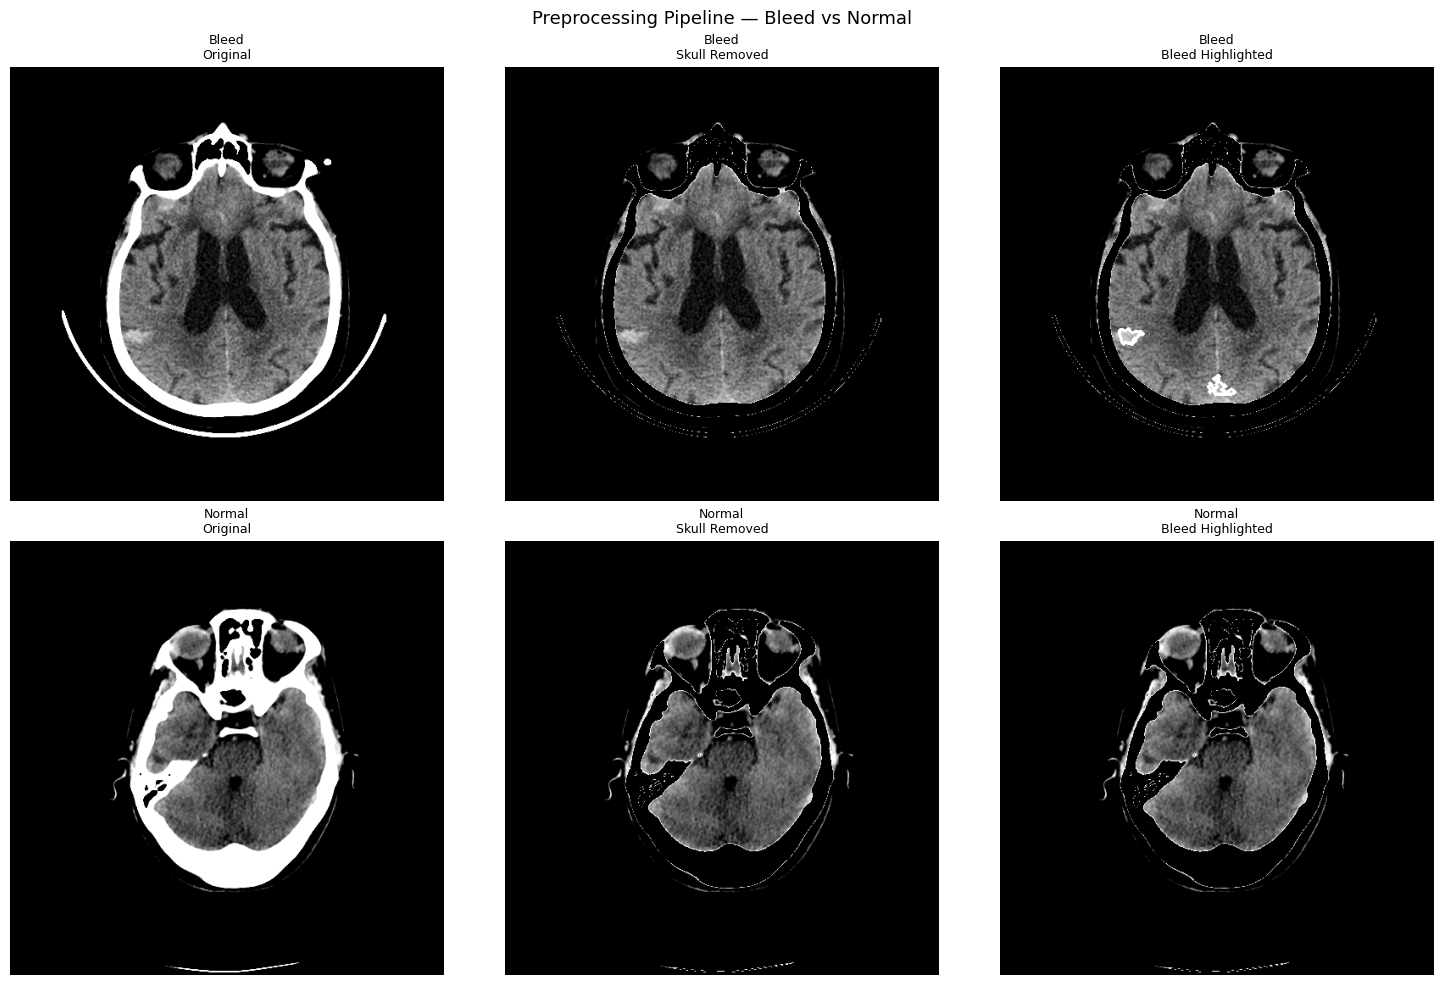


--- Heatmap: Unknown slice 0 ---


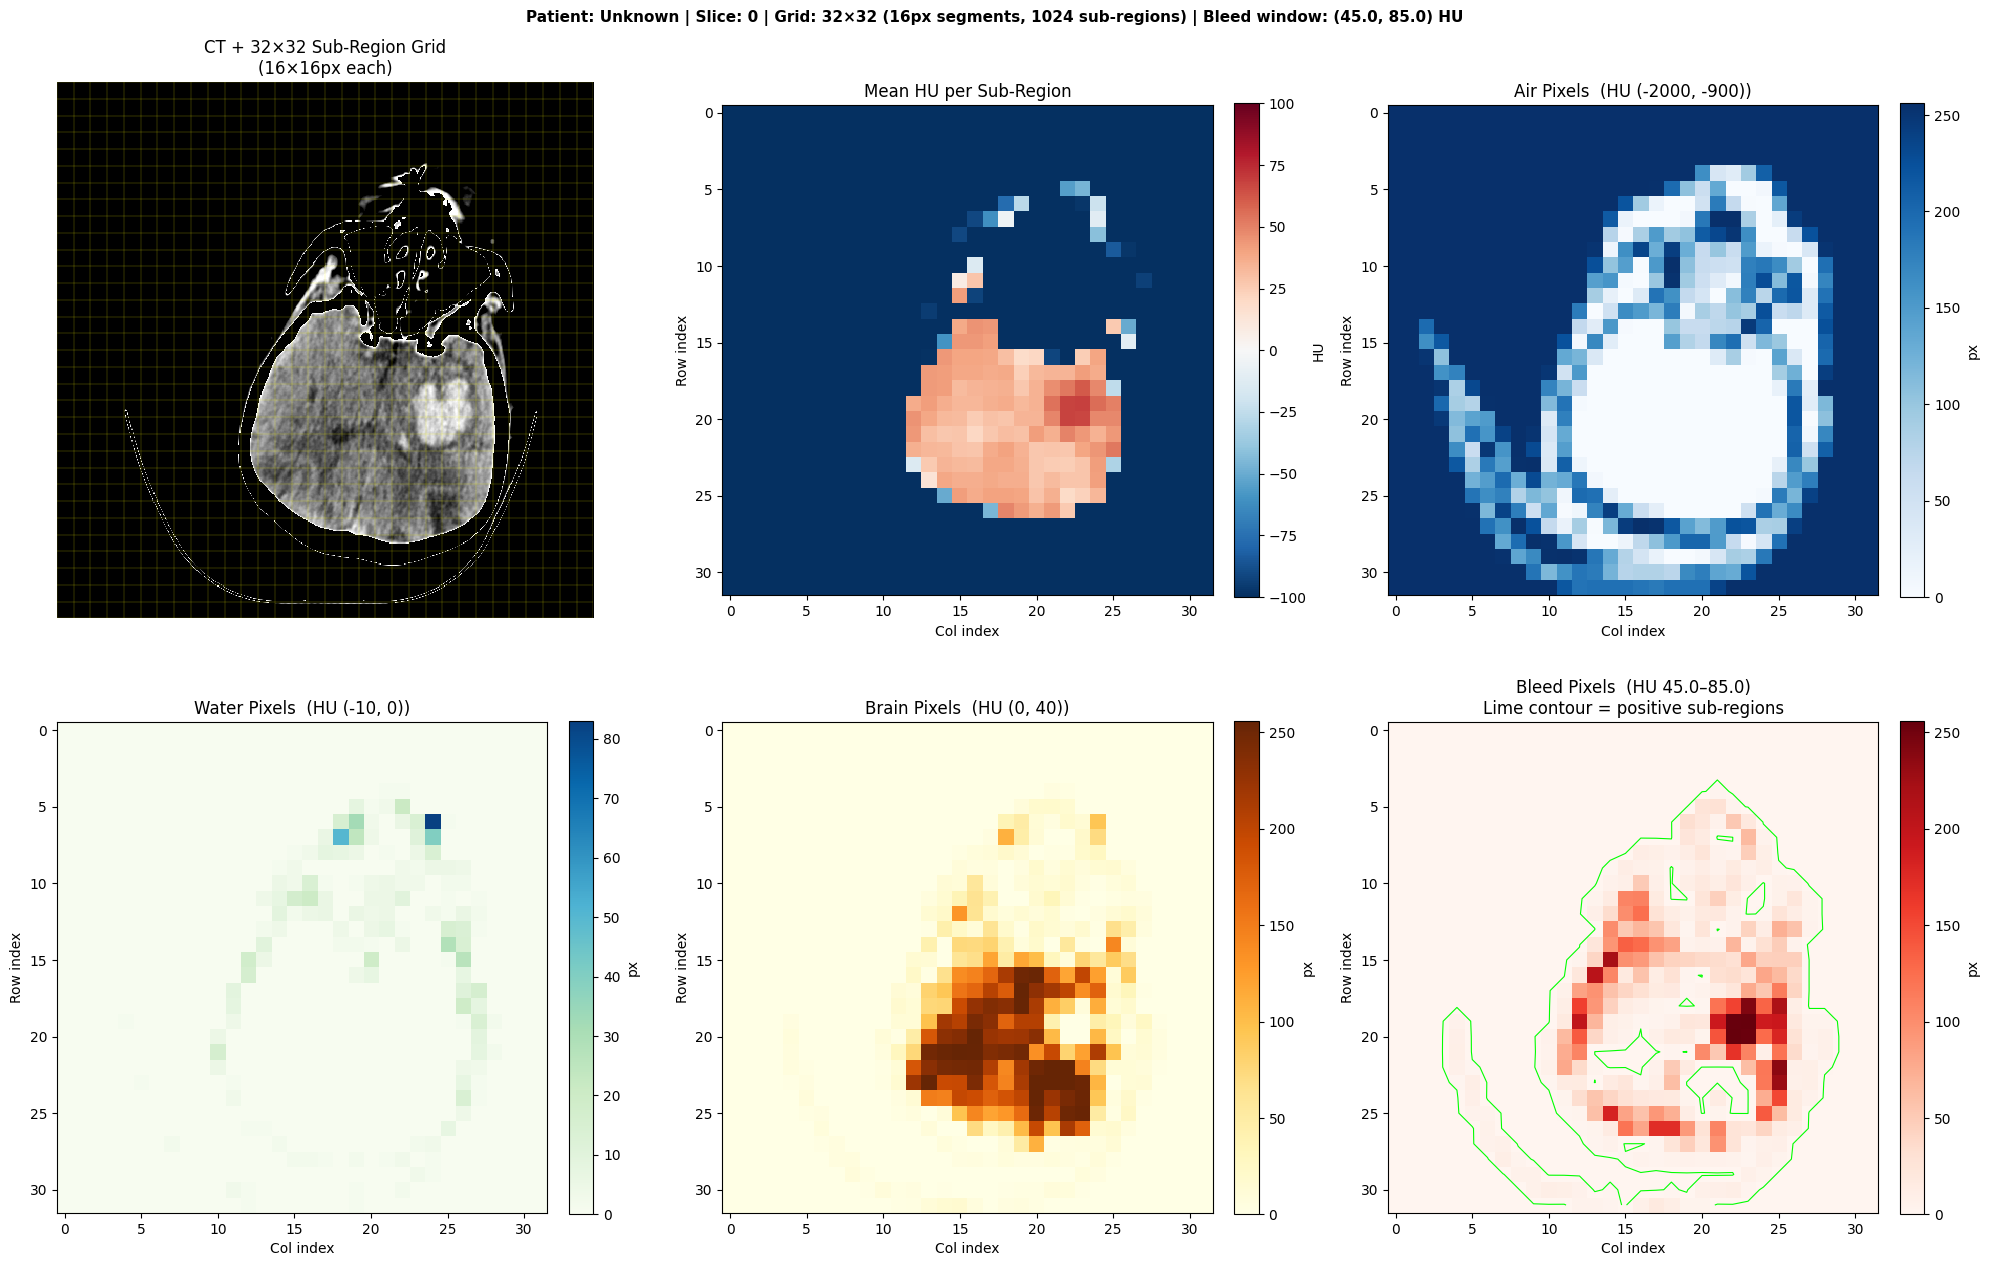


  Top bleed sub-regions (slice 0):
  Grid(r,c)    Pixel origin (r,c)       Bleed px    Mean HU
  --------------------------------------------------------
  (19,23)      (304,368)                      256         68.6
  (20,22)      (320,352)                      256         67.3
  (19,22)      (304,352)                      254         67.5
  (20,23)      (320,368)                      253         67.1
  (18,23)      (288,368)                      242         62.8
  (22,25)      (352,400)                      236         53.5
  (23,25)      (368,400)                      228         52.8
  (15,14)      (240,224)                      221         54.3
  (18,25)      (288,400)                      216         55.0
  (16,13)      (256,208)                      206         58.0


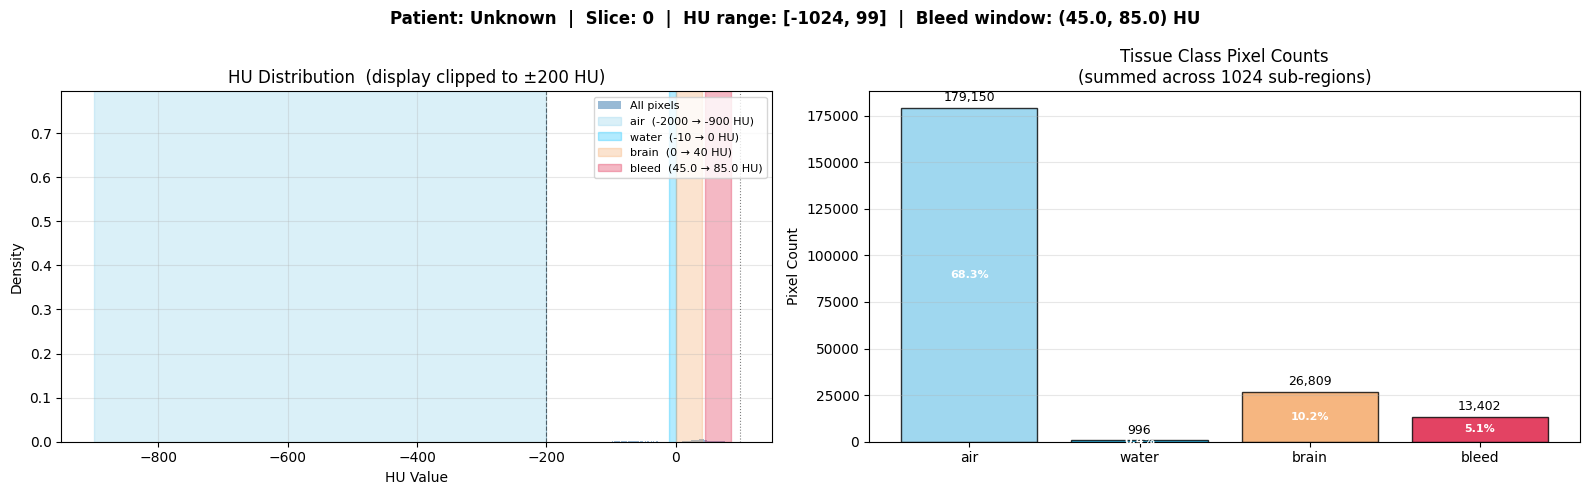

   Slice stats — min=-1024.0  max=99.0  mean=-725.4  std=433.7 HU
        air : 179,150 px  ( 68.3%)
      water :     996 px  (  0.4%)
      brain :  26,809 px  ( 10.2%)
      bleed :  13,402 px  (  5.1%)


In [16]:
# ── Visualise preprocessing + segment analysis on sample slices ───────────────
# Shows one Bleed and one Normal slice through all visualisation functions.

import random

def brain_window(hu_image, ww=80, wl=40):
    lo = wl - ww / 2; hi = wl + ww / 2
    return np.clip((hu_image - lo) / (hi - lo), 0, 1)


def show_preprocessing_row(dcm_orig, label_name, ax_row):
    rel          = os.path.relpath(dcm_orig, DATA_ROOT)
    skull_path   = os.path.join(skull_removed_dir,     rel)
    high_path    = os.path.join(bleed_highlighted_dir, rel)
    for ax, path, title in zip(ax_row,
                                [dcm_orig, skull_path, high_path],
                                ['Original', 'Skull Removed', 'Bleed Highlighted']):
        if os.path.exists(path):
            _, _, _, hu = read_dicom_hu(path)
            ax.imshow(brain_window(hu), cmap='gray', vmin=0, vmax=1)
        else:
            ax.text(0.5, 0.5, 'Not found', ha='center', va='center',
                    transform=ax.transAxes)
        ax.set_title(f'{label_name}\n{title}', fontsize=9)
        ax.axis('off')


bleed_files  = df_orig[df_orig['label'] == 1]['full_path'].tolist()
normal_files = df_orig[df_orig['label'] == 0]['full_path'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Preprocessing Pipeline — Bleed vs Normal', fontsize=13)
if bleed_files:  show_preprocessing_row(random.choice(bleed_files),  'Bleed',  axes[0])
if normal_files: show_preprocessing_row(random.choice(normal_files), 'Normal', axes[1])
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'preprocessing_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Show heatmaps + HU analysis for one Bleed slice
bleed_entries = [(k, v) for k, v in slice_segment_results.items() if v['label'] == 1]
if bleed_entries:
    sample_path, sample_data = random.choice(bleed_entries)
    print(f"\n--- Heatmap: {sample_data['patient_id']} "
          f"slice {sample_data['instance_num']} ---")
    plot_segment_heatmaps(
        seg_results          = sample_data['seg_results'],
        hu_array             = sample_data['hu_array'],
        calibrated_thresholds= sample_data['cal_thresh'],
        patient_id           = sample_data['patient_id'],
        slice_idx            = sample_data['instance_num'],
    )
    plot_hu_analysis(
        hu_array             = sample_data['hu_array'],
        seg_results          = sample_data['seg_results'],
        patient_id           = sample_data['patient_id'],
        slice_idx            = sample_data['instance_num'],
        calibrated_thresholds= sample_data['cal_thresh'],
    )

---
## Part C — Deep Learning Pipeline (v13)
**DRRN → LapSRN → U-Net Bleed Segmentation → Triage Scorer**

**v3 mask generation:** `build_bleed_mask_from_dicom()` now uses the updated `get_bleed_mask()` which internally applies `calibrate_bleed_threshold()` + `apply_boundary_exclusion()` — so DL training targets are consistent with the preprocessing outputs.

In [17]:
import math, time
from PIL import Image as PILImage
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity  as ssim_metric

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from torchvision import models
from torchvision.models import VGG19_Weights
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [18]:
# ── CBAM Attention (from v12/v7) ──────────────────────────────────────────────

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel_size)
    def forward(self, x):
        x = x * self.ca(x)
        return x * self.sa(x)

print("✅ CBAM ready.")

✅ CBAM ready.


In [19]:
# ── Loss Functions (from v12/v10) ─────────────────────────────────────────────

class PerceptualLossNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=VGG19_Weights.DEFAULT).features
        self.slice1 = nn.Sequential(*[vgg[i] for i in range(4)])
        self.slice2 = nn.Sequential(*[vgg[i] for i in range(4, 9)])
        self.slice3 = nn.Sequential(*[vgg[i] for i in range(9, 14)])
        for p in self.parameters(): p.requires_grad = False
    def forward(self, x):
        x3 = x.repeat(1, 3, 1, 1)
        h1 = self.slice1(x3); h2 = self.slice2(h1); h3 = self.slice3(h2)
        return [h1, h2, h3]

class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3): super().__init__(); self.eps = eps
    def forward(self, pred, target):
        return torch.mean(torch.sqrt((pred - target)**2 + self.eps**2))

class SRLoss(nn.Module):
    def __init__(self, perceptual_weight=0.1, device='cpu'):
        super().__init__()
        self.charb    = CharbonnierLoss()
        self.perc_net = PerceptualLossNetwork().to(device); self.perc_net.eval()
        self.perc_w   = perceptual_weight
    def forward(self, pred, target):
        l_c = self.charb(pred, target)
        pf  = self.perc_net(pred); tf = self.perc_net(target)
        l_p = sum(F.l1_loss(p, t) for p, t in zip(pf, tf)) / 3
        return l_c + self.perc_w * l_p

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, eps=1e-6):
        super().__init__(); self.bce = nn.BCEWithLogitsLoss()
        self.bw = bce_weight; self.eps = eps
    def forward(self, pred, target):
        bce   = self.bce(pred, target)
        p     = torch.sigmoid(pred)
        inter = (p * target).sum()
        dice  = 1 - (2*inter + self.eps) / (p.sum() + target.sum() + self.eps)
        return self.bw * bce + (1 - self.bw) * dice

sr_loss_fn     = SRLoss(perceptual_weight=0.1, device=str(device))
seg_loss_fn    = BCEDiceLoss()
triage_loss_fn = nn.MSELoss()
print("✅ Loss functions ready.")

✅ Loss functions ready.


In [20]:
# ── Dataset ───────────────────────────────────────────────────────────────────
# v3: uses df from load_dicom_metadata(); mask built via updated get_bleed_mask()

IMG_SIZE = 128


def hu_to_normalised(hu_image, ww=80, wl=40):
    """Apply standard brain CT window (WW=80, WL=40) → [0,1]."""
    lo = wl - ww / 2; hi = wl + ww / 2
    return np.clip((hu_image - lo) / (hi - lo), 0, 1).astype(np.float32)


def add_degradation(img_tensor, noise_std=0.05, blur_kernel=3):
    noisy = img_tensor + torch.randn_like(img_tensor) * noise_std
    if blur_kernel > 1:
        pad   = blur_kernel // 2
        noisy = F.avg_pool2d(noisy.unsqueeze(0), blur_kernel,
                             stride=1, padding=pad).squeeze(0)
    return noisy.clamp(0, 1)


def build_bleed_mask_from_dicom(dcm_path, label_val):
    """
    Build pixel-level bleed mask using the full preprocessing pipeline.
    v3: get_bleed_mask() internally uses calibrated threshold + boundary exclusion.
    Returns a boolean numpy array or None (caller uses ones/zeros fallback).
    """
    if label_val == 0:
        return None
    rel        = os.path.relpath(dcm_path, DATA_ROOT)
    skull_path = os.path.join(skull_removed_dir, rel)
    load_path  = skull_path if os.path.exists(skull_path) else dcm_path
    try:
        _, _, _, hu = read_dicom_hu(load_path)
        brain_mask  = get_brain_mask(hu, rim_erosion=BRAIN_RIM_EROSION)
        valid, _    = is_valid_slice(brain_mask, hu)
        if not valid:
            return None
        bleed_mask = get_bleed_mask(hu, brain_mask)  # calibrated + boundary-excluded
        return bleed_mask if bleed_mask.any() else None
    except Exception:
        return None


class HaemorrhageCTDataset(Dataset):
    """
    v3: Initialised from the metadata DataFrame (df) rather than a plain
    file list, so PatientID / InstanceNumber are available for sorting.
    """
    def __init__(self, df_subset: pd.DataFrame,
                 augment=False, img_size=256, sr_scale=4):
        self.samples  = list(zip(df_subset['full_path'], df_subset['label']))
        self.img_size = img_size
        self.sr_scale = sr_scale
        self.aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.4),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=15, p=0.4),
        ]) if augment else None

    def __len__(self): return len(self.samples)

    def _load_slice(self, orig_path):
        rel        = os.path.relpath(orig_path, DATA_ROOT)
        skull_path = os.path.join(skull_removed_dir, rel)
        load_path  = skull_path if os.path.exists(skull_path) else orig_path
        _, _, _, hu = read_dicom_hu(load_path)   # FIX 1 inside
        img = hu_to_normalised(hu)
        img_pil = PILImage.fromarray((img * 255).astype(np.uint8)).resize(
            (self.img_size, self.img_size), PILImage.LANCZOS)
        return np.array(img_pil, dtype=np.float32) / 255.0

    def __getitem__(self, idx):
        orig_path, label_val = self.samples[idx]
        img      = self._load_slice(orig_path)
        raw_mask = build_bleed_mask_from_dicom(orig_path, label_val)

        if label_val == 0:
            mask = np.zeros_like(img, dtype=np.float32)
        elif raw_mask is not None:
            mask_pil = PILImage.fromarray(raw_mask.astype(np.uint8) * 255).resize(
                (self.img_size, self.img_size), PILImage.NEAREST)
            mask = (np.array(mask_pil) > 127).astype(np.float32)
        else:
            mask = np.ones_like(img, dtype=np.float32)

        img  = img[...,  np.newaxis]
        mask = mask[..., np.newaxis]
        if self.aug:
            out  = self.aug(image=img, mask=mask)
            img, mask = out['image'], out['mask']

        img  = torch.from_numpy(img).permute(2, 0, 1).float()
        mask = (torch.from_numpy(mask).permute(2, 0, 1).float() > 0).float()
        clean  = img.clone()
        lr_img = add_degradation(img.clone())

        H, W = img.shape[-2], img.shape[-1]
        s = self.sr_scale
        hr_img  = F.interpolate(img.unsqueeze(0), size=(H*s, W*s),
                                mode='bilinear', align_corners=False).squeeze(0)
        mask_hr = F.interpolate(mask.unsqueeze(0), size=(H*s, W*s),
                                mode='nearest').squeeze(0)
        return lr_img, clean, hr_img, mask_hr


# ── Stratified splits using the metadata DataFrame ────────────────────────────
train_val_df, test_df = train_test_split(
    df_orig, test_size=0.15, random_state=42, stratify=df_orig['label'])
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15, random_state=42, stratify=train_val_df['label'])

train_dataset = HaemorrhageCTDataset(train_df, augment=True,  img_size=IMG_SIZE)
val_dataset   = HaemorrhageCTDataset(val_df,   augment=False, img_size=IMG_SIZE)
test_dataset  = HaemorrhageCTDataset(test_df,  augment=False, img_size=IMG_SIZE)

BATCH = 8
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Train balance — Normal:{(train_df['label']==0).sum()} | Bleeding:{(train_df['label']==1).sum()}")
lr_, clean_, hr_, msk_ = train_dataset[0]
print(f"Sample shapes — LR:{lr_.shape}  Clean:{clean_.shape}  HR:{hr_.shape}  Mask:{msk_.shape}")

Train: 3988 | Val: 704 | Test: 828
Train balance — Normal:3198 | Bleeding:790
Sample shapes — LR:torch.Size([1, 128, 128])  Clean:torch.Size([1, 128, 128])  HR:torch.Size([1, 512, 512])  Mask:torch.Size([1, 512, 512])


In [22]:
# ── Model definitions (DRRN, LapSRN, U-Net, TriageScorer) ────────────────────
# Identical to previous version — CBAM + BatchNorm + both v13 LapSRN bug fixes.
NUM_EPOCHS = 50
class ResidualUnit(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.cbam  = CBAM(channels)
    def forward(self, x):
        out = self.cbam(self.conv2(F.relu(self.bn2(self.conv1(F.relu(self.bn1(x)))))))
        return out + x

class DRRN(nn.Module):
    def __init__(self, in_channels=1, num_features=64, B=1, U=5):
        super().__init__(); self.B = B; self.U = U
        self.head           = nn.Conv2d(in_channels, num_features, 3, padding=1)
        self.recursive_unit = ResidualUnit(num_features)
        self.tail           = nn.Conv2d(num_features, in_channels, 3, padding=1)
    def forward(self, x):
        from torch.utils.checkpoint import checkpoint
        identity = x; x = F.relu(self.head(x))
        for _ in range(self.B):
            for _ in range(self.U):
                x = checkpoint(self.recursive_unit, x, use_reentrant=False)
        return self.tail(x) + identity

class LapSRN_Level(nn.Module):
    def __init__(self, in_channels=1, num_features=64, num_convs=5):
        super().__init__()
        layers = [nn.Conv2d(num_features, num_features, 3, padding=1),
                  nn.BatchNorm2d(num_features), nn.LeakyReLU(0.2, inplace=True)]
        for _ in range(num_convs - 1):
            layers += [nn.Conv2d(num_features, num_features, 3, padding=1),
                       nn.BatchNorm2d(num_features), nn.LeakyReLU(0.2, inplace=True)]
        layers.append(CBAM(num_features))
        self.feature_extract = nn.Sequential(*layers)
        self.img_residual    = nn.ConvTranspose2d(num_features, in_channels, 4, stride=2, padding=1)
        self.feat_up         = nn.ConvTranspose2d(num_features, num_features, 4, stride=2, padding=1)
    def forward(self, feat, img):
        feat     = self.feature_extract(feat)
        residual = self.img_residual(feat)   # Fix 2: before feat_up
        feat     = F.leaky_relu(self.feat_up(feat), 0.2)
        img_up   = F.interpolate(img, scale_factor=2, mode='bilinear', align_corners=False)
        return feat, img_up + residual

class LapSRN(nn.Module):
    def __init__(self, in_channels=1, num_features=64, num_convs=5, scale=4):
        super().__init__(); self.num_levels = int(math.log2(scale))
        self.head = nn.Sequential(
            nn.Conv2d(in_channels, num_features, 3, padding=1),
            nn.BatchNorm2d(num_features), nn.LeakyReLU(0.2, inplace=True))
        self.levels = nn.ModuleList(
            [LapSRN_Level(in_channels, num_features, num_convs)
             for _ in range(self.num_levels)])
    def forward(self, x):
        feat = self.head(x); img = x; out = []
        for lv in self.levels: feat, img = lv(feat, img); out.append(img)
        return out

class DoubleConv(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(inplace=True))
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[32,64,128,256]):
        super().__init__()
        self.downs = nn.ModuleList(); self.ups = nn.ModuleList()
        self.pool  = nn.MaxPool2d(2)
        ch = in_channels
        for f in features: self.downs.append(DoubleConv(ch, f)); ch = f
        self.bottleneck = nn.Sequential(DoubleConv(features[-1], features[-1]*2),
                                        CBAM(features[-1]*2))
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
            self.ups.append(DoubleConv(f*2, f))
        self.final = nn.Conv2d(features[0], out_channels, 1)
    def forward(self, x):
        skips = []
        for d in self.downs: x = d(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x); skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x); s = skips[i//2]
            if x.shape != s.shape: x = F.interpolate(x, size=s.shape[2:])
            x = self.ups[i+1](torch.cat([s, x], dim=1))
        return self.final(x)

class TriageScorer(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32,  64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128,256, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(4))
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(256*4*4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, x): return self.head(self.features(x)) * 100.0

def mask_to_triage_score(mask_hr):
    frac = mask_hr.view(mask_hr.size(0), -1).mean(dim=1, keepdim=True)
    return (frac * 100.0).clamp(0, 100)

drrn_model   = DRRN(in_channels=1, num_features=64, B=1, U=5).to(device)
lapsrn_model = LapSRN(in_channels=1, num_features=64, num_convs=5, scale=4).to(device)
unet_model   = UNet(in_channels=1, out_channels=1).to(device)
triage_model = TriageScorer(in_channels=1).to(device)

print(f"DRRN     : {sum(p.numel() for p in drrn_model.parameters()):,} params")
print(f"LapSRN   : {sum(p.numel() for p in lapsrn_model.parameters()):,} params")
print(f"U-Net    : {sum(p.numel() for p in unet_model.parameters()):,} params")
print(f"Triage   : {sum(p.numel() for p in triage_model.parameters()):,} params")

# ── Loss functions ────────────────────────────────────────────────
drrn_loss_fn   = nn.L1Loss().to(device)
sr_loss_fn     = SRLoss().to(device)
seg_loss_fn    = nn.BCEWithLogitsLoss().to(device)
triage_loss_fn = nn.MSELoss().to(device)

print("✅ Loss functions defined:")
print("   • drrn_loss_fn   : L1Loss")
print("   • sr_loss_fn     : SRLoss (Charbonnier + Perceptual)")
print("   • seg_loss_fn    : BCEWithLogitsLoss")
print("   • triage_loss_fn : MSELoss")

# ── Optimizer & scheduler ─────────────────────────────────────────
all_params = (list(drrn_model.parameters())   + list(lapsrn_model.parameters()) +
              list(unet_model.parameters())   + list(triage_model.parameters()))
optimizer  = optim.Adam(all_params, lr=1e-4, weight_decay=1e-5)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"✅ Optimizer: Adam  lr=1e-4")
print(f"   Scheduler: CosineAnnealingLR  T_max={NUM_EPOCHS}")

# ── Memory check ──────────────────────────────────────────────────
print(f"\nGPU allocated after setup: {torch.cuda.memory_allocated()/1024**2:.1f} MB")

DRRN     : 75,811 params
LapSRN   : 505,798 params
U-Net    : 7,795,331 params
Triage   : 1,453,185 params
✅ Loss functions defined:
   • drrn_loss_fn   : L1Loss
   • sr_loss_fn     : SRLoss (Charbonnier + Perceptual)
   • seg_loss_fn    : BCEWithLogitsLoss
   • triage_loss_fn : MSELoss
✅ Optimizer: Adam  lr=1e-4
   Scheduler: CosineAnnealingLR  T_max=50

GPU allocated after setup: 42.4 MB


In [23]:
# ── Metrics ───────────────────────────────────────────────────────────────────

def compute_psnr_ssim(pred_batch, target_batch):
    psnr_vals, ssim_vals = [], []
    for p, t in zip(pred_batch.detach().cpu().numpy(),
                    target_batch.detach().cpu().numpy()):
        pi = np.clip(p.squeeze(), 0, 1); ti = np.clip(t.squeeze(), 0, 1)
        psnr_vals.append(psnr_metric(ti, pi, data_range=1.0))
        ssim_vals.append(ssim_metric(ti, pi, data_range=1.0))
    return np.mean(psnr_vals), np.mean(ssim_vals)

def dice_coefficient(pred, target, threshold=0.5, eps=1e-6):
    pred  = (torch.sigmoid(pred) > threshold).float()
    inter = (pred * target).sum()
    return (2*inter + eps) / (pred.sum() + target.sum() + eps)

def iou_score(pred, target, threshold=0.5, eps=1e-6):
    pred  = (torch.sigmoid(pred) > threshold).float()
    inter = (pred * target).sum()
    return (inter + eps) / (pred.sum() + target.sum() - inter + eps)

print("✅ Metrics ready.")

✅ Metrics ready.


In [38]:
# At the top of the training setup cell, add:
os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"
scaler = torch.cuda.amp.GradScaler()

In [26]:
# ── Training setup & loop ─────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
os.environ["MIOPEN_SUPPRESS_WARNINGS"] = "1"

from collections import defaultdict
scaler = torch.cuda.amp.GradScaler()
all_params = (list(drrn_model.parameters())   + list(lapsrn_model.parameters()) +
              list(unet_model.parameters())   + list(triage_model.parameters()))
optimizer  = optim.Adam(all_params, lr=1e-4, weight_decay=1e-5)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

LAMBDA_DRRN=1.0; LAMBDA_SR2=0.5; LAMBDA_SR4=1.0; LAMBDA_SEG=1.0; LAMBDA_TRIAGE=0.1
NUM_EPOCHS   = 50
CKPT_PATH    = os.path.join(PROCESSED_DIR, 'best_haemorrhage_model.pth')
best_val_loss = float('inf')

history = {k: [] for k in ['train_loss','val_loss','train_psnr_d','val_psnr_d',
                            'train_psnr_sr','val_psnr_sr','train_ssim_sr','val_ssim_sr',
                            'train_dice','val_dice','train_iou','val_iou']}

def run_epoch(loader, train=True):
    for m in [drrn_model, lapsrn_model, unet_model, triage_model]:
        m.train() if train else m.eval()

    metrics = defaultdict(float)
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for lr_img, clean, hr_img, mask_hr in loader:
            lr_img  = lr_img.to(device,  non_blocking=True)
            clean   = clean.to(device,   non_blocking=True)
            hr_img  = hr_img.to(device,  non_blocking=True)
            mask_hr = mask_hr.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():
                denoised = drrn_model(lr_img)
                l_drrn   = drrn_loss_fn(denoised, clean) * LAMBDA_DRRN

                sr2, sr4 = lapsrn_model(denoised)
                hr2      = F.interpolate(hr_img, size=sr2.shape[-2:],
                                         mode='bilinear', align_corners=False)
                l_sr2    = sr_loss_fn(sr2, hr2)  * LAMBDA_SR2
                l_sr4    = sr_loss_fn(sr4, hr_img) * LAMBDA_SR4

                seg_pred  = unet_model(sr4)
                mhr_r     = (F.interpolate(mask_hr, size=seg_pred.shape[-2:],
                             mode='nearest')
                             if seg_pred.shape[-2:] != mask_hr.shape[-2:]
                             else mask_hr)
                l_seg     = seg_loss_fn(seg_pred, mhr_r) * LAMBDA_SEG

                triage_s  = triage_model(sr4)
                l_triage  = triage_loss_fn(triage_s,
                             (mask_hr.flatten(1).any(1).float().unsqueeze(1))
                             ) * LAMBDA_TRIAGE

                loss = l_drrn + l_sr2 + l_sr4 + l_seg + l_triage

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            metrics['loss']     += loss.item()
            metrics['l_drrn']   += l_drrn.item()
            metrics['l_sr2']    += l_sr2.item()
            metrics['l_sr4']    += l_sr4.item()
            metrics['l_seg']    += l_seg.item()
            metrics['l_triage'] += l_triage.item()

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}


print(f"Training for {NUM_EPOCHS} epochs on {device}\n")
start_time = time.time()

os.environ["PYTORCH_HIP_ALLOC_CONF"] = "expandable_segments:True"

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=4, pin_memory=True,
                          persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False,
                          num_workers=4, pin_memory=True,
                          persistent_workers=True)

print(f"Training for {NUM_EPOCHS} epochs on {device}")

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tm = run_epoch(train_loader, train=True)
    
    # Only validate every 5 epochs — saves ~20% total time
    if epoch % 5 == 0 or epoch == NUM_EPOCHS:
        vm = run_epoch(val_loader, train=False)
        print(f"Ep {epoch:03d} | "
              f"loss {tm['loss']:.4f} | "
              f"val {vm['loss']:.4f} | "
              f"seg {tm['l_seg']:.4f} | "
              f"{time.time()-t0:.0f}s")
    else:
        print(f"Ep {epoch:03d} | "
              f"loss {tm['loss']:.4f} | "
              f"seg {tm['l_seg']:.4f} | "
              f"{time.time()-t0:.0f}s")

    scheduler.step()

    if epoch % 10 == 0:
        torch.save({
            'epoch': epoch,
            'drrn':   drrn_model.state_dict(),
            'lapsrn': lapsrn_model.state_dict(),
            'unet':   unet_model.state_dict(),
            'triage': triage_model.state_dict(),
            'opt':    optimizer.state_dict(),
        }, CKPT_PATH)

print(f"\nTraining complete in {(time.time()-start_time)/60:.1f} min.")

Training for 50 epochs on cuda

Training for 50 epochs on cuda
Ep 001 | loss 0.4556 | seg 0.3418 | 54s
Ep 002 | loss 0.3812 | seg 0.2979 | 51s
Ep 003 | loss 0.3534 | seg 0.2717 | 50s
Ep 004 | loss 0.3346 | seg 0.2583 | 51s
Ep 005 | loss 0.3149 | val 0.3494 | seg 0.2427 | 59s
Ep 006 | loss 0.3094 | seg 0.2373 | 51s
Ep 007 | loss 0.3043 | seg 0.2367 | 50s
Ep 008 | loss 0.2971 | seg 0.2300 | 50s
Ep 009 | loss 0.2952 | seg 0.2307 | 51s
Ep 010 | loss 0.2884 | val 0.3824 | seg 0.2255 | 54s
Ep 011 | loss 0.2815 | seg 0.2183 | 51s
Ep 012 | loss 0.2755 | seg 0.2121 | 50s
Ep 013 | loss 0.2701 | seg 0.2089 | 50s
Ep 014 | loss 0.2713 | seg 0.2090 | 50s
Ep 015 | loss 0.2689 | val 0.3079 | seg 0.2082 | 54s
Ep 016 | loss 0.2639 | seg 0.2048 | 50s
Ep 017 | loss 0.2626 | seg 0.2032 | 50s
Ep 018 | loss 0.2592 | seg 0.2005 | 50s
Ep 019 | loss 0.2532 | seg 0.1951 | 50s
Ep 020 | loss 0.2498 | val 0.2863 | seg 0.1930 | 54s
Ep 021 | loss 0.2448 | seg 0.1876 | 50s
Ep 022 | loss 0.2471 | seg 0.1906 | 50s
Ep 02

In [28]:
# ── Test set evaluation ───────────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device)
for m, k in [(drrn_model,'drrn'),(lapsrn_model,'lapsrn'),
             (unet_model,'unet'),(triage_model,'triage')]:
    m.load_state_dict(ckpt[k]); m.eval()

test_m = run_epoch(test_loader, train=False)
print("=" * 60)
print("   FINAL TEST RESULTS — Brain CT Haemorrhage Pipeline v3")
print("=" * 60)
print(f"  Total Loss              : {test_m['loss']:.4f}")
print(f"  DRRN Loss               : {test_m['l_drrn']:.4f}")
print(f"  SR Loss (2×)            : {test_m['l_sr2']:.4f}")
print(f"  SR Loss (4×)            : {test_m['l_sr4']:.4f}")
print(f"  Segmentation Loss       : {test_m['l_seg']:.4f}")
print(f"  Triage Loss             : {test_m['l_triage']:.4f}")
print("=" * 60)
print("\nv3 pipeline summary:")
print("  [Cell 3]  load_dicom_metadata() — robust recursive loader, full DataFrame")
print("  [Cell 3b] segment_slice / analyse_segment — 16px dense grid utilities")
print("  [Cell 4]  Dense grid analysis — 32×32 sub-regions, calibrated per slice")
print("  [Cell 5]  plot_segment_heatmaps — 6-panel heatmap + Top-10 bleed table")
print("  [Cell 5b] plot_hu_analysis — HU histogram + tissue bar chart")
print("  [Cell 6]  calibrate_bleed_threshold — dynamic per-slice bleed window")
print("  [Cell 7]  apply_boundary_exclusion — removes air-adjacent artefacts")
print("  [Pre-A]   Skull removal — all 5 original fixes")
print("  [Pre-B]   Bleed highlighting — calibrated + boundary-excluded masks")
print("  [DRRN]    CT denoising — CBAM + BatchNorm + Perceptual loss")
print("  [LapSRN]  4× SR — CBAM + BatchNorm, both v13 bug fixes")
print("  [U-Net]   Bleed segmentation — trained on calibrated preprocessing masks")
print("  [Triage]  Priority score — proportional to bleed area")

   FINAL TEST RESULTS — Brain CT Haemorrhage Pipeline v3
  Total Loss              : 0.2890
  DRRN Loss               : 0.0377
  SR Loss (2×)            : 0.0147
  SR Loss (4×)            : 0.0258
  Segmentation Loss       : 0.1964
  Triage Loss             : 0.0144

v3 pipeline summary:
  [Cell 3]  load_dicom_metadata() — robust recursive loader, full DataFrame
  [Cell 3b] segment_slice / analyse_segment — 16px dense grid utilities
  [Cell 4]  Dense grid analysis — 32×32 sub-regions, calibrated per slice
  [Cell 5]  plot_segment_heatmaps — 6-panel heatmap + Top-10 bleed table
  [Cell 5b] plot_hu_analysis — HU histogram + tissue bar chart
  [Cell 6]  calibrate_bleed_threshold — dynamic per-slice bleed window
  [Cell 7]  apply_boundary_exclusion — removes air-adjacent artefacts
  [Pre-A]   Skull removal — all 5 original fixes
  [Pre-B]   Bleed highlighting — calibrated + boundary-excluded masks
  [DRRN]    CT denoising — CBAM + BatchNorm + Perceptual loss
  [LapSRN]  4× SR — CBAM + Batc

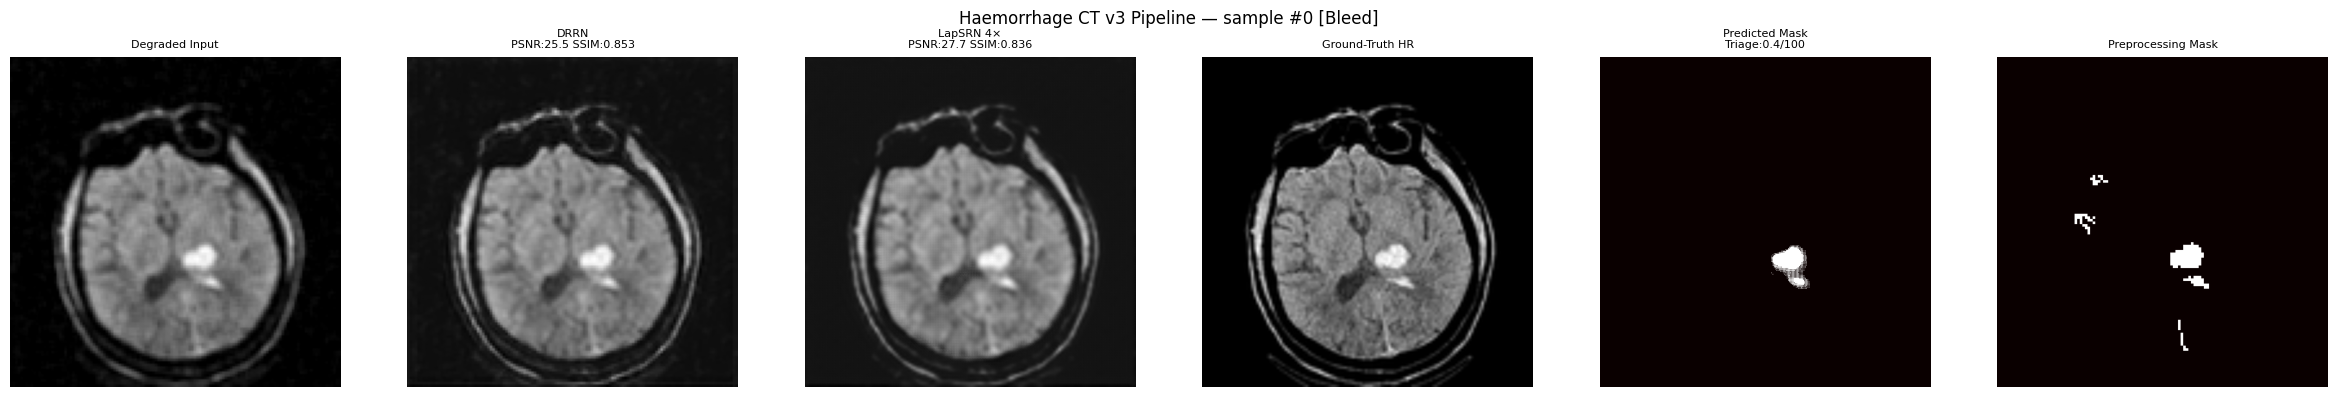

  [Bleed]  Triage: 0.4/100  🟢 NORMAL


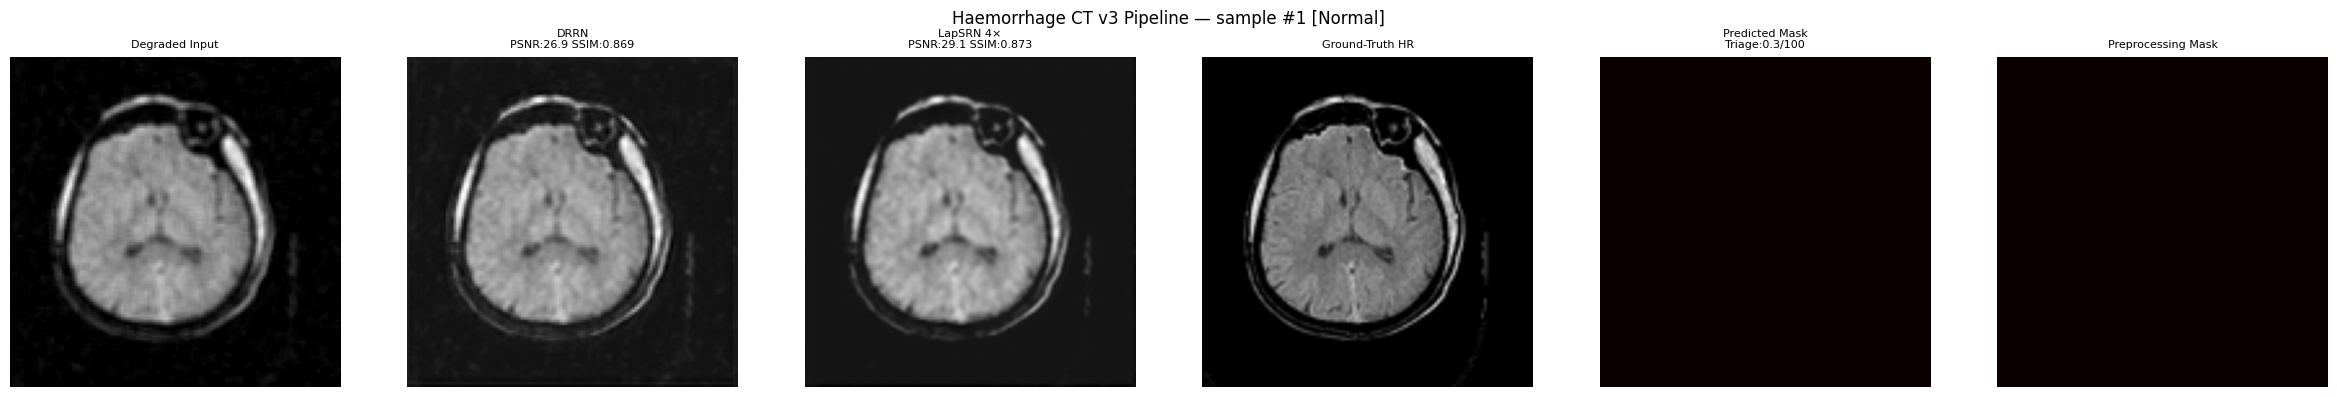

  [Normal]  Triage: 0.3/100  🟢 NORMAL


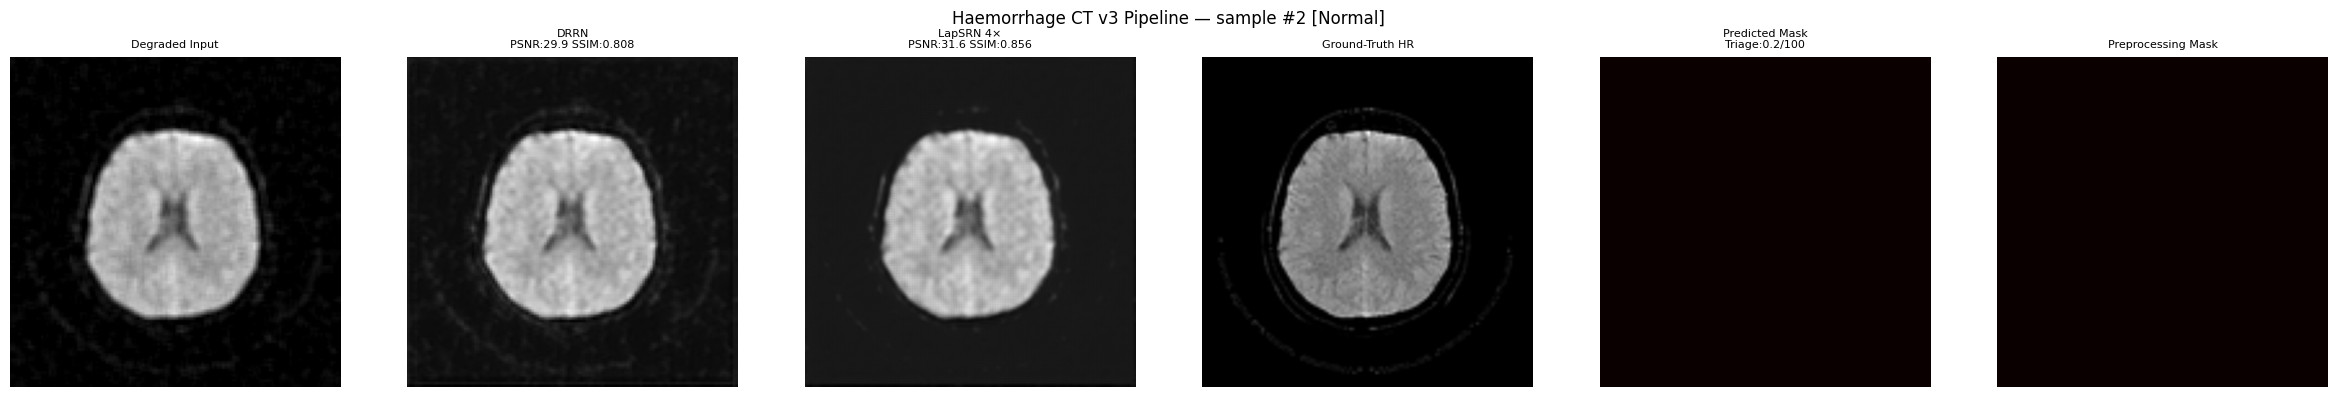

  [Normal]  Triage: 0.2/100  🟢 NORMAL


In [29]:
# ── Full pipeline visualisation on test samples ───────────────────────────────

def show_pipeline(dataset, idx=0):
    lr_img, clean, hr_img, mask_hr = dataset[idx]
    with torch.no_grad():
        lr_t=lr_img.unsqueeze(0).to(device); clean_t=clean.unsqueeze(0).to(device)
        hr_t=hr_img.unsqueeze(0).to(device)
        denoised = drrn_model(lr_t)
        sr4      = lapsrn_model(denoised)[1]
        seg_pred = torch.sigmoid(unet_model(sr4))
        triage_s = triage_model(sr4).item()
    p_d, s_d = compute_psnr_ssim(denoised, clean_t)
    p_sr, s_sr = compute_psnr_ssim(sr4, hr_t)
    _, lbl = dataset.samples[idx]
    cls_name = 'Bleed' if lbl == 1 else 'Normal'

    panels = [
        (lr_img.squeeze().cpu().numpy(),         'Degraded Input', 'gray'),
        (denoised.squeeze().cpu().numpy(),        f'DRRN\nPSNR:{p_d:.1f} SSIM:{s_d:.3f}', 'gray'),
        (sr4.squeeze().cpu().numpy(),             f'LapSRN 4×\nPSNR:{p_sr:.1f} SSIM:{s_sr:.3f}', 'gray'),
        (hr_img.squeeze().cpu().numpy(),          'Ground-Truth HR', 'gray'),
        ((seg_pred>0.5).float().squeeze().cpu().numpy(), f'Predicted Mask\nTriage:{triage_s:.1f}/100', 'hot'),
        (mask_hr.squeeze().cpu().numpy(),         'Preprocessing Mask', 'hot'),
    ]
    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    fig.suptitle(f'Haemorrhage CT v3 Pipeline — sample #{idx} [{cls_name}]', fontsize=12)
    for ax, (img, title, cmap) in zip(axes, panels):
        ax.imshow(img, cmap=cmap); ax.set_title(title, fontsize=8); ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(PROCESSED_DIR, f'pipeline_sample{idx}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  [{cls_name}]  Triage: {triage_s:.1f}/100  "
          f"{'🔴 HIGH PRIORITY' if triage_s > 60 else '🟢 NORMAL'}")


for i in range(min(3, len(test_dataset))):
    show_pipeline(test_dataset, idx=i)

In [30]:
# ── ONNX export ───────────────────────────────────────────────────────────────
import torch.onnx
onnx_dir = os.path.join(PROCESSED_DIR, 'onnx'); os.makedirs(onnx_dir, exist_ok=True)

def export_onnx(model, dummy, path, name):
    model.eval()
    torch.onnx.export(model, dummy, path, export_params=True, opset_version=12,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input':{0:'batch'},'output':{0:'batch'}})
    print(f"  {name:20s} → {path}  ({os.path.getsize(path)/1e6:.1f} MB)")

h, w = IMG_SIZE, IMG_SIZE
print("Exporting ONNX models…")
export_onnx(drrn_model,   torch.randn(1,1,h,w).to(device),     os.path.join(onnx_dir,'drrn.onnx'),   'DRRN')
export_onnx(lapsrn_model, torch.randn(1,1,h,w).to(device),     os.path.join(onnx_dir,'lapsrn.onnx'), 'LapSRN')
export_onnx(unet_model,   torch.randn(1,1,h*4,w*4).to(device), os.path.join(onnx_dir,'unet.onnx'),   'U-Net')
export_onnx(triage_model, torch.randn(1,1,h*4,w*4).to(device), os.path.join(onnx_dir,'triage.onnx'), 'Triage')
print("Done.")

Exporting ONNX models…
  DRRN                 → ./processed/onnx/drrn.onnx  (0.3 MB)
  LapSRN               → ./processed/onnx/lapsrn.onnx  (1.8 MB)
  U-Net                → ./processed/onnx/unet.onnx  (31.2 MB)
  Triage               → ./processed/onnx/triage.onnx  (5.8 MB)
Done.


In [31]:
import shutil, os

print("Zipping ./processed — this may take a few minutes...")
shutil.make_archive(
    base_name='processed',   # output filename: processed.zip
    format='zip',
    root_dir='.',
    base_dir='processed'
)

size_mb = os.path.getsize('processed.zip') / 1024**2
print(f"✅ Done — processed.zip ({size_mb:.1f} MB)")
print("Download it from the Jupyter file browser on the left panel.")

Zipping ./processed — this may take a few minutes...
✅ Done — processed.zip (2061.7 MB)
Download it from the Jupyter file browser on the left panel.
